# **Capstone Project — Job Posting Salary & Job Title Prediction**
## Data Tech Stack Pipeline

**Tujuan Model:** Memprediksi `job_title` berdasarkan fitur pekerjaan menggunakan MLP.

---

# **1. Mendefinisikan Pertanyaan Bisnis**

Berikut lima pertanyaan bisnis yang **terukur** beserta metrik keberhasilannya:

| No | Pertanyaan | Metrik Keberhasilan |
|---|-----------|---------------------|
| 1 | Bagaimana tren pertumbuhan rata-rata salary Tech vs Non-Tech pada level Mid dari tahun ke tahun (2020–2024)? | Δ rata-rata salary tahunan (%) per kelompok |
| 2 | Apa 5 industri dengan rata-rata gaji tertinggi secara konsisten setiap tahun (2020–2024)? | Ranking konsistensi masuk Top-5 selama ≥ 3 tahun |
| 3 | Apa 5 Job Title dengan rata-rata gaji tertinggi di seluruh periode data? | Rata-rata `salary_midpoint` per `job_title` |
| 4 | Apa 10 keahlian teknis dengan frekuensi permintaan tertinggi di pasar kerja? | Frekuensi kemunculan skill di seluruh postingan |
| 5 | Apa 10 keahlian teknis yang memberikan rata-rata penawaran gaji tertinggi? | Rata-rata `salary_midpoint` per skill |
| 6 | Berapa persentase kenaikan salary dari setiap transisi experience level (Entry→Mid→Senior→Lead→Executive), dan transisi mana yang memberikan lompatan terbesar? | Persentase kenaikan salary tiap transisi Experience level |

# **2. Import Library**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

print("Libraries loaded successfully.")

Libraries loaded successfully.


# **3. Data Wrangling**

## 3.1 Data Gathering

In [ ]:
# Load Data
df_raw = pd.read_csv('job_posting_carpathmu.csv')
print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Dataset loaded: 50,743 rows × 26 columns


,job_id,post_date,year,month,industry,company,company_size,location,state,work_type,...,salary_midpoint,skills_required,benefits,days_to_fill,applicant_count,seniority,is_tech_role,education_background,min_GPA_requirement,job_title
0,J0000001,2023-12-30,2023,12,Education,Summit Digital,Enterprise (5000+),Remote,Remote,On-site,...,139000,Python|Financial Modeling|Derivatives,Dental/Vision|Stock Options|401k,29,41,Junior,0,Informatics Engineering|Mathematics|Statistics,3.30,Quantitative Analyst
1,J0000002,2022-05-25,2022,5,Education,Nexus AI,Large (1001-5000),"Boston, MA",MA,On-site,...,362000,Redis|Docker|Python|Java|AWS,Health Insurance|Flexible Hours|Remote Work|De...,20,88,Executive,0,Informatics Engineering,3.76,Backend Developer
2,J0000003,2020-09-08,2020,9,Consulting,Summit Corp,Mid-size (201-1000),"Atlanta, GA",GA,On-site,...,136000,Compensation|Talent Acquisition|Employment Law,Flexible Hours|Stock Options|Parental Leave,33,52,Senior,0,Law,3.59,HR Manager
3,J0000004,2022-01-21,2022,1,Healthcare,Summit Systems,Large (1001-5000),"New York, NY",NY,Hybrid,...,306000,Terraform|GCP|Microservices,401k|Learning Budget|Remote Work|Unlimited PTO...,15,142,Senior,0,Information Systems,3.48,Cloud Architect
4,J0000005,2024-11-07,2024,11,Manufacturing,Stellar Ventures,Large (1001-5000),"Washington, DC",DC,On-site,...,185000,Git|Kubernetes|Java|Docker|Python|REST APIs,Stock Options|Dental/Vision|Remote Work|Health...,53,342,Mid,0,Information Systems|Informatics Engineering|Co...,3.12,Software Engineer


## 3.2 Data Assessing

Pemeriksaan dilakukan pada empat aspek utama:
1. Tipe Data & Info Umum
2. Ringkasan Statistik
3. Missing Values
4. Data Duplikat

### 3.2.1 Pemeriksaan Tipe Data

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50743 entries, 0 to 50742
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_id                50743 non-null  object 
 1   post_date             50743 non-null  object 
 2   year                  50743 non-null  int64  
 3   month                 50743 non-null  int64  
 4   industry              50384 non-null  object 
 5   company               50743 non-null  object 
 6   company_size          50743 non-null  object 
 7   location              50743 non-null  object 
 8   state                 50743 non-null  object 
 9   work_type             50743 non-null  object 
 10  experience_level      50743 non-null  object 
 11  experience_min_yrs    50743 non-null  int64  
 12  experience_max_yrs    50743 non-null  int64  
 13  education_required    50743 non-null  object 
 14  salary_min            50743 non-null  int64  
 15  salary_max         

**Insght:** Kolom `post_date` bertipe `object` (string), seharusnya `datetime`.

### 3.2.2 Ringkasan Parameter Statistik

In [ ]:
df_raw.describe(include='all')

,job_id,post_date,year,month,industry,company,company_size,location,state,work_type,...,salary_midpoint,skills_required,benefits,days_to_fill,applicant_count,seniority,is_tech_role,education_background,min_GPA_requirement,job_title
count,50743,50743,50743.000000,50743.000000,50384,50743,50743,50743,50743,50743,...,50743.000000,50394,50743,50743.000000,50743.000000,50398,50743.000000,50743,50743.000000,50743
unique,50000,1827,NaN,NaN,11,180,5,16,14,3,...,NaN,33570,15704,NaN,NaN,5,NaN,73,NaN,20
top,J0017731,2022-05-17,NaN,NaN,Finance,Catalyst Labs,Mid-size (201-1000),Remote,CA,On-site,...,NaN,Performance Management|Talent Acquisition|Comp...,Parental Leave|Stock Options,NaN,NaN,Mid,NaN,Informatics Engineering,NaN,Research Scientist
freq,3,45,NaN,NaN,4662,327,12675,6817,7901,24997,...,NaN,25,172,NaN,NaN,17721,NaN,3994,NaN,2643
mean,NaN,NaN,2021.996374,6.531108,NaN,NaN,NaN,NaN,NaN,NaN,...,162530.792425,NaN,NaN,28.855704,123.732771,NaN,0.089766,NaN,3.398958,NaN
std,NaN,NaN,1.417369,3.455394,NaN,NaN,NaN,NaN,NaN,NaN,...,74133.896213,NaN,NaN,18.667446,117.855349,NaN,0.285849,NaN,0.230690,NaN
min,NaN,NaN,2020.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,36000.000000,NaN,NaN,5.000000,5.000000,NaN,0.000000,NaN,3.000000,NaN
25%,NaN,NaN,2021.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,109000.000000,NaN,NaN,16.000000,52.000000,NaN,0.000000,NaN,3.200000,NaN
50%,NaN,NaN,2022.000000,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,147000.000000,NaN,NaN,24.000000,90.000000,NaN,0.000000,NaN,3.400000,NaN
75%,NaN,NaN,2023.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,198000.000000,NaN,NaN,36.000000,153.000000,NaN,0.000000,NaN,3.600000,NaN


### 3.2.3 Pemeriksaan Missing Value

In [ ]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                 Missing Count  Missing %
industry                   359       0.71
skills_required            349       0.69
seniority                  345       0.68


**Insght:** Missing value pada kolom `industry`, `skills_required`, dan `seniority` Kurang dari 1% yang berarti aman untuk di drop.

### 3.2.4 Pemeriksaan Data Duplikat

In [ ]:
print(f"Jumlah duplikat: {df_raw.duplicated().sum()}")

Jumlah duplikat: 223


## 3.3 Data Cleaning

| Masalah | Penanganan | Alasan |
|---|---|---|
| Kolom tidak relevan bisnis | Drop `company`, `location`, `state`, `benefits`, `days_to_fill`, `applicant_count`, `is_tech_role` | Tidak digunakan di analisis maupun fitur model |
| Redundan waktu | Drop `month`, `year` | Informasi ada di `post_date` yang sudah di-parse |
| Redundan experience | Drop `experience_min_yrs`, `experience_max_yrs` | Sudah terangkum di `experience_level` dan `seniority` |
| Redundan salary | Drop `salary_min`, `salary_max` | Menggunakan `salary_midpoint` sebagai representasi |
| Tipe data salah | Convert `post_date` → `datetime` | Diperlukan analisis tren temporal |
| Missing values (< 1%) | `dropna()` | Jumlah sangat kecil, aman dihapus |
| Duplikat (223 baris) | `drop_duplicates()` | Mencegah bias statistik dan model |

> **NOtee:** Kolom `year` dan `seniority` di-drop dari DataFrame utama setelah cleaning, namun nilai-nilainya diekstrak terlebih dahulu sebelum drop untuk keperluan analisis EDA.

### 3.3.1 Ekstrak Kolom Analisis Sebelum Drop

In [ ]:
df = df_raw.copy()
df['post_date'] = pd.to_datetime(df['post_date'])
df['year_eda']      = df['year']
df['seniority_eda'] = df['seniority']

### 3.3.2 Drop Kolom & Perbaikan Tipe Data

In [ ]:
columns_to_drop = [
    'company', 'location', 'state', 'benefits', 'days_to_fill',
    'applicant_count', 'is_tech_role', 'month', 'year',
    'experience_min_yrs', 'experience_max_yrs',
    'salary_min', 'salary_max'
]

df.drop(columns=columns_to_drop, inplace=True)
print(f"Kolom tersisa after drop: {df.columns.tolist()}")

Kolom tersisa after drop: ['job_id', 'post_date', 'industry', 'company_size', 'work_type', 'experience_level', 'education_required', 'salary_midpoint', 'skills_required', 'seniority', 'education_background', 'min_GPA_requirement', 'job_title', 'year_eda', 'seniority_eda']


### 3.3.3 Penanganan Missing Value & Duplikat

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset after cleaning: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.info()

Dataset after cleaning: 50,000 rows × 15 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   job_id                50000 non-null  object        
 1   post_date             50000 non-null  datetime64[ns]
 2   industry              50000 non-null  object        
 3   company_size          50000 non-null  object        
 4   work_type             50000 non-null  object        
 5   experience_level      50000 non-null  object        
 6   education_required    50000 non-null  object        
 7   salary_midpoint       50000 non-null  int64         
 8   skills_required       50000 non-null  object        
 9   seniority             50000 non-null  object        
 10  education_background  50000 non-null  object        
 11  min_GPA_requirement   50000 non-null  float64       
 12  job_title             500

**Insight:**
*   Dataset telah bersih dan lengkap, hasil akhir terdapat 50.000 baris × 15 kolom, seluruh kolom non-null, dan tidak ada missing values tersisa.
*    Kolom yang tersisa sudah merepresentasikan informasi yang relevan dengan konteks bisnis dengan tipe data yang tepat untuk analisis.

### 3.3.4 Simpan Clean Data

In [ ]:
df.to_csv('jobs_postings_clean.csv', index=False)
print("Clean data saved to 'jobs_postings_clean.csv'")

Clean data saved to 'jobs_postings_clean.csv'


# **4. Exploratory Data Analysis (EDA)**

EDA dilakukan untuk memahami distribusi, pola, dan anomali setiap kolom sebelum analisis bisnis.


## 4.1 Eksplorasi Kolom `job_title`

Unique Job Titles: 20
job_title
Research Scientist           2589
Quantitative Analyst         2582
Business Analyst             2576
Senior Software Engineer     2550
Cybersecurity Analyst        2540
Machine Learning Engineer    2536
Marketing Manager            2513
Backend Developer            2508
Operations Manager           2504
Cloud Architect              2500
DevOps Engineer              2497
Data Scientist               2497
Data Analyst                 2490
Financial Analyst            2485
UX Designer                  2457
Software Engineer            2444
Product Manager              2442
Data Engineer                2442
HR Manager                   2440
Frontend Developer           2408


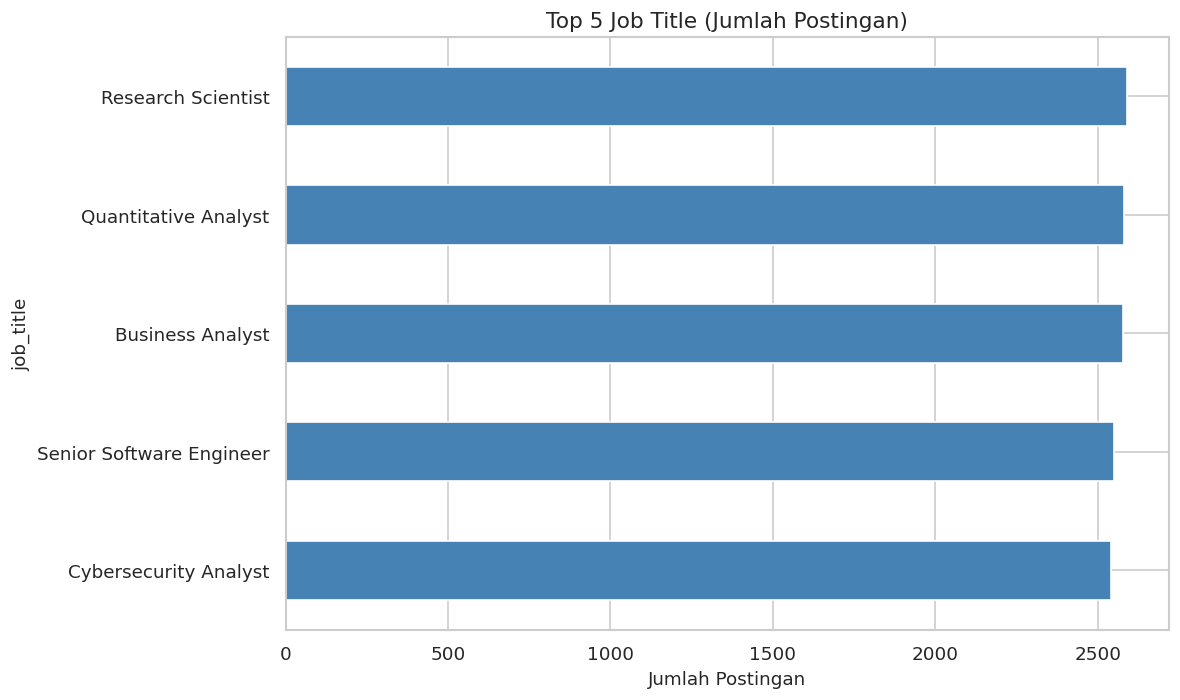

In [ ]:
print(f"Unique Job Titles: {df['job_title'].nunique()}")
vc = df['job_title'].value_counts()
print(vc.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
bars = vc.head().sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 5 Job Title (Jumlah Postingan)')
ax.set_xlabel('Jumlah Postingan')
plt.tight_layout()
plt.show()

**Insight:**
  * Terdapat 20 job title
  * Research Scientist adalah job title paling banyak diposting (2,589 postingan)
  * Distribusi cukup merata antar job title (min=2408, max=2589)

## 4.2 Eksplorasi Kolom `industry`

Unique Industries: 11
industry
Finance          4623
Healthcare       4602
Media            4600
Retail           4587
Manufacturing    4559
Government       4547
Consulting       4544
Education        4540
E-commerce       4503
Tech             4484
Logistics        4411
Name: count, dtype: int64


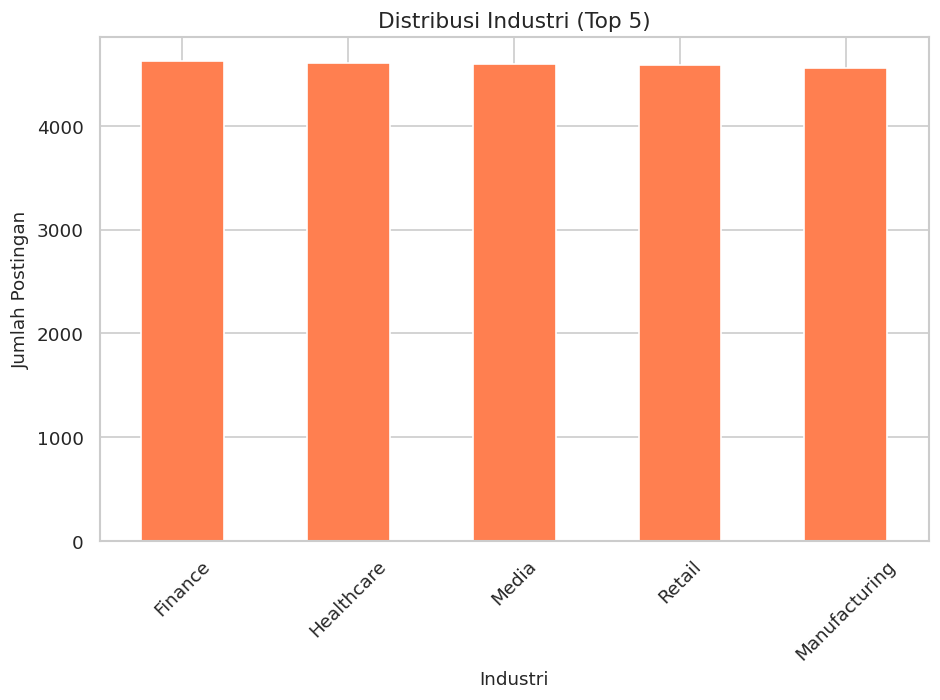

In [ ]:
print(f"Unique Industries: {df['industry'].nunique()}")
vc_ind = df['industry'].value_counts()
print(vc_ind)

fig, ax = plt.subplots(figsize=(8, 6)) # Changed to single subplot and adjusted figure size
vc_ind.head(5).plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Distribusi Industri (Top 5)')
ax.set_xlabel('Industri')
ax.set_ylabel('Jumlah Postingan')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Insight:**

  * Terdapat 11 industri, dengan distribusi relatif merata
  * Finance merupakan industri paling banyak diposting (4623 Postingan)
  

## 4.3 Eksplorasi Kolom `work_type`

Unique Work Types: 3
work_type
On-site    24641
Hybrid     16178
Remote      9181
Name: count, dtype: int64


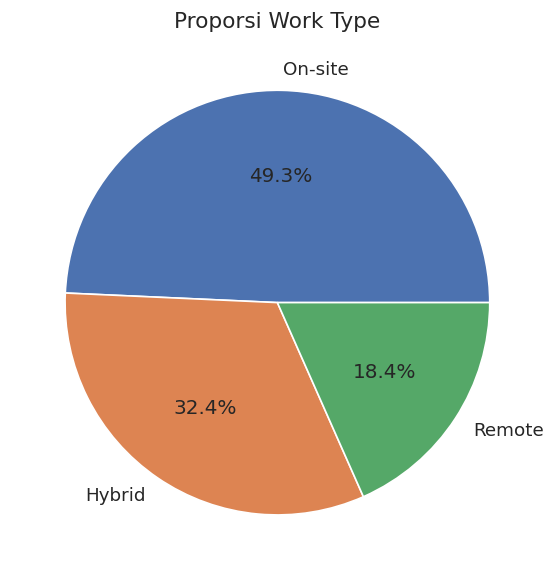

In [ ]:
print(f"Unique Work Types: {df['work_type'].nunique()}")
print(df['work_type'].value_counts())

fig, ax = plt.subplots(figsize=(6, 5))
df['work_type'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%',
                                     colors=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Proporsi Work Type')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Insight:**
* Terdapat 3 Work Type
* On-Site merupakan work type dengan persentase tertinggi sebesar 49.3% (24641 postingan)

## 4.4 Eksplorasi Kolom `experience_level`

Unique Experience Levels: 5
experience_level
Mid (3-5 yrs)          17580
Senior (6-9 yrs)       14058
Entry (0-2 yrs)        10985
Lead (10-15 yrs)        4941
Executive (15+ yrs)     2436
Name: count, dtype: int64


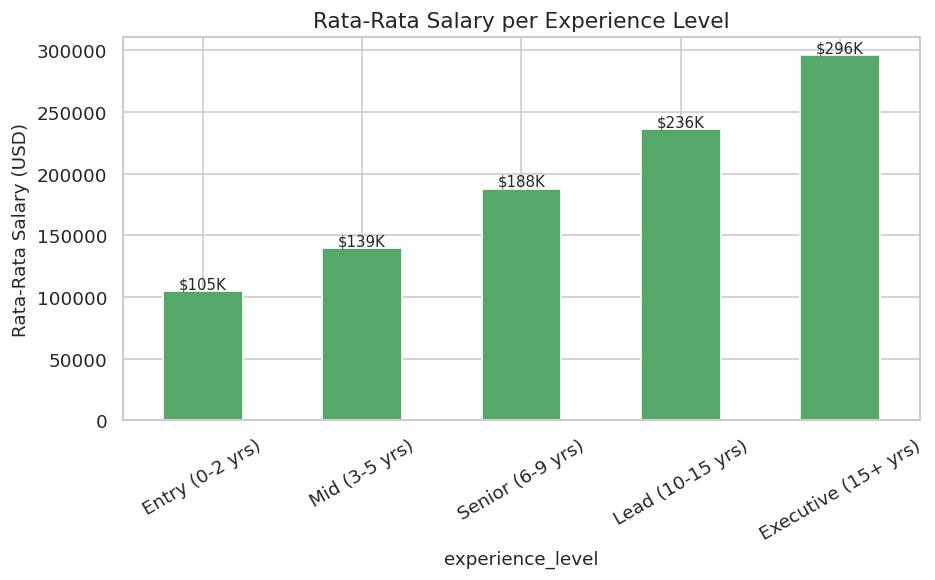

In [ ]:
print(f"Unique Experience Levels: {df['experience_level'].nunique()}")
print(df['experience_level'].value_counts())

exp_order = ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10-15 yrs)', 'Executive (15+ yrs)']
exp_salary = df.groupby('experience_level')['salary_midpoint'].mean().reindex(exp_order)

fig, ax = plt.subplots(figsize=(8, 5))

exp_salary.plot(kind='bar', ax=ax, color='#55A868', edgecolor='white')
ax.set_title('Rata-Rata Salary per Experience Level')
ax.set_ylabel('Rata-Rata Salary (USD)')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'${p.get_height()/1000:.0f}K', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**
  * Terdapat 5 Experience level
  * Mid level merupakan Experience level tertinggi (17580 Postingan)
  * Semakin tinggi experience level, rata-rata salary cenderung meningkat secara monoton


---


    Entry (0-2 yrs)          : 104,772
    Mid (3-5 yrs)            : 139,432
    Senior (6-9 yrs)         : 187,746
    Lead (10-15 yrs)         : 236,087
    Executive (15+ yrs)      : 295,898

## 4.5 Eksplorasi Kolom `education_required`

Unique Education Required: 6
education_required
Bachelor's     22326
Master's       14197
PhD             5081
Associate       3976
High School     2470
Bootcamp        1950
Name: count, dtype: int64


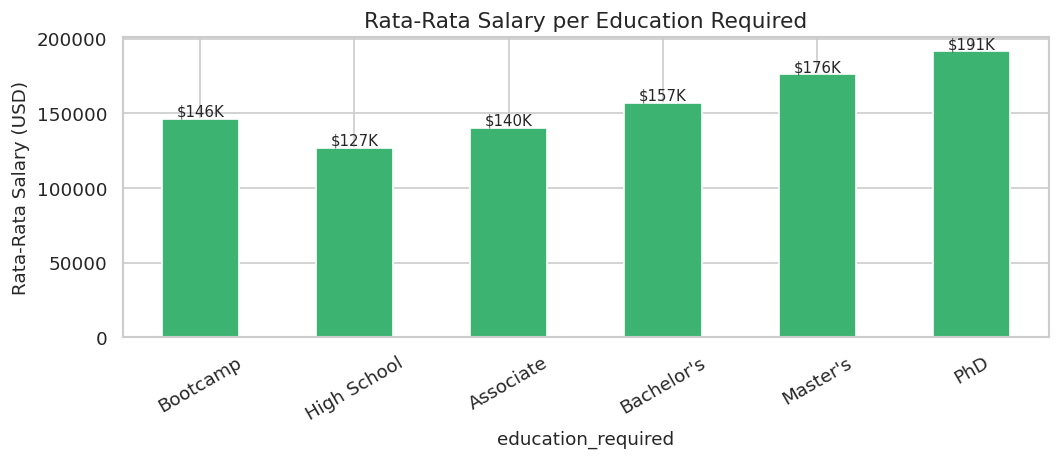

In [ ]:
print(f"Unique Education Required: {df['education_required'].nunique()}")
print(df['education_required'].value_counts())

edu_order = [ "Bootcamp", "High School", "Associate", "Bachelor's", "Master's", "PhD"]
edu_salary = df.groupby('education_required')['salary_midpoint'].mean().reindex(edu_order).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
bars = edu_salary.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Rata-Rata Salary per Education Required')
ax.set_ylabel('Rata-Rata Salary (USD)')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'${p.get_height()/1000:.0f}K', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**

  * Terdapat 6 Education Required
  * Bachelor's adalah requirement paling umum
  * PhD memiliki rata-rata salary tertinggi ($191,428)

## 4.6 Eksplorasi Kolom `skills_required` (Multi-label)

Unique Skills: 82
skills_required
Python                    16457
SQL                       14004
AWS                        9805
Docker                     7070
Kubernetes                 6983
Statistics                 6100
Excel                      5077
Tableau                    4953
R                          4526
TensorFlow                 4506
REST APIs                  4282
Git                        4280
Java                       4247
Spark                      4165
Agile                      3743
Stakeholder Management     3724
A/B Testing                3456
Figma                      3377
Power BI                   3149
Financial Modeling         3084
Machine Learning           3015
CI/CD                      2859
Microservices              2838
Terraform                  2758
Compensation               1966
Talent Acquisition         1952
Performance Management     1943
HRIS                       1936
Employment Law             1934
Requirements Gathering     1927
SIEM  

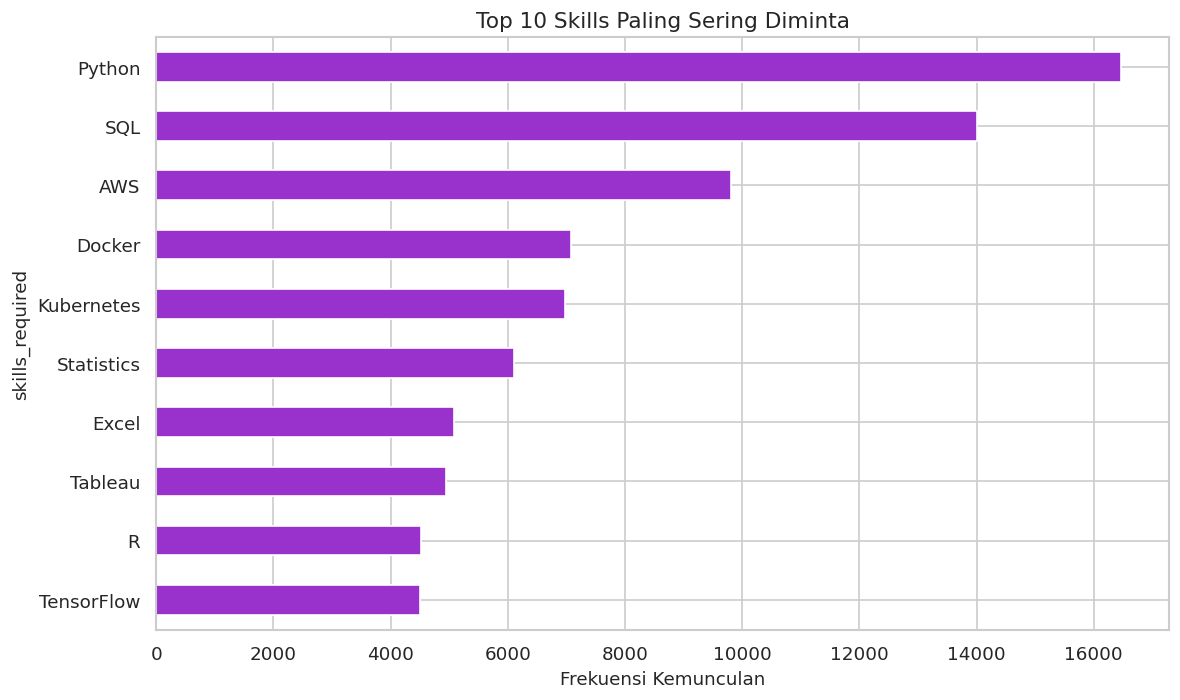

In [ ]:
all_skills = df['skills_required'].str.split('|').explode().str.strip()
skill_counts = all_skills.value_counts()
print(f"Unique Skills: {len(skill_counts)}")
print(skill_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
skill_counts.head(10).sort_values().plot(kind='barh', ax=ax, color='darkorchid')
ax.set_title('Top 10 Skills Paling Sering Diminta')
ax.set_xlabel('Frekuensi Kemunculan')
plt.tight_layout()
plt.show()

**Insight:**

* Terdapat 82 skill unik dalam dataset
* Skill paling banyak diminta: Python (16,457 kemunculan)

## 4.7 Eksplorasi Kolom `education_background`

Unique Education Backgrounds: 13
education_background
Informatics Engineering    23281
Mathematics                13442
Statistics                 13325
Information Systems         9971
Computer Science            9941
Management                  9097
Psychology                  6030
Law                         6001
Communication Science       3058
Administration              3005
Industrial Engineering       947
Mechanical Engineering       929
Electrical Engineering       896
Name: count, dtype: int64


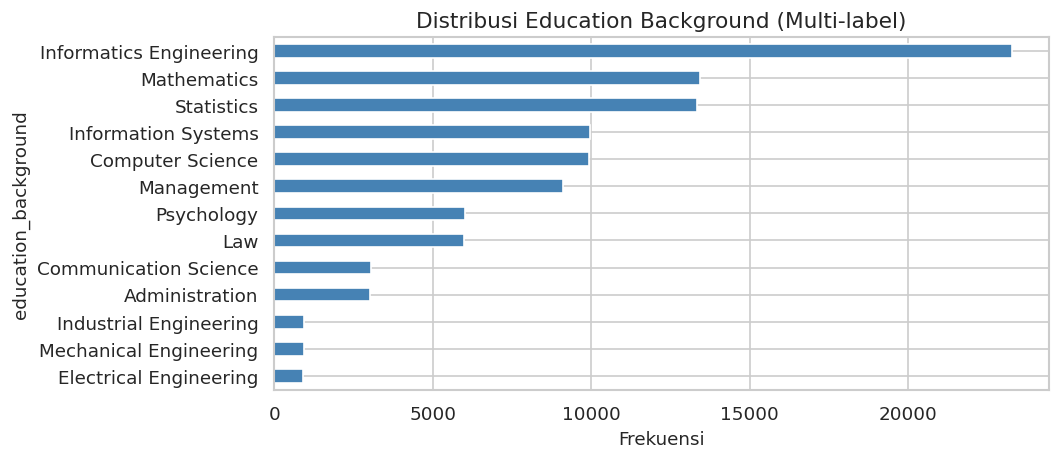

In [ ]:
all_edu_bg = df['education_background'].str.split('|').explode().str.strip()
edu_bg_counts = all_edu_bg.value_counts()
print(f"Unique Education Backgrounds: {len(edu_bg_counts)}")
print(edu_bg_counts)

fig, ax = plt.subplots(figsize=(9, 4))
edu_bg_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Distribusi Education Background (Multi-label)')
ax.set_xlabel('Frekuensi')
plt.tight_layout()
plt.show()

**Insight:**

*   Terdapat 13 latar belakang pendidikan yang unik.
*   Informatics Engineering adalah latar belakang pendidikan yang paling banyak dicari dalam postingan kerja (23,281 kemunculan).
*   Latar belakang pendidikan lain yang umum adalah Matematika dan Statistika.

## 4.8 Eksplorasi Distribusi `salary_midpoint`

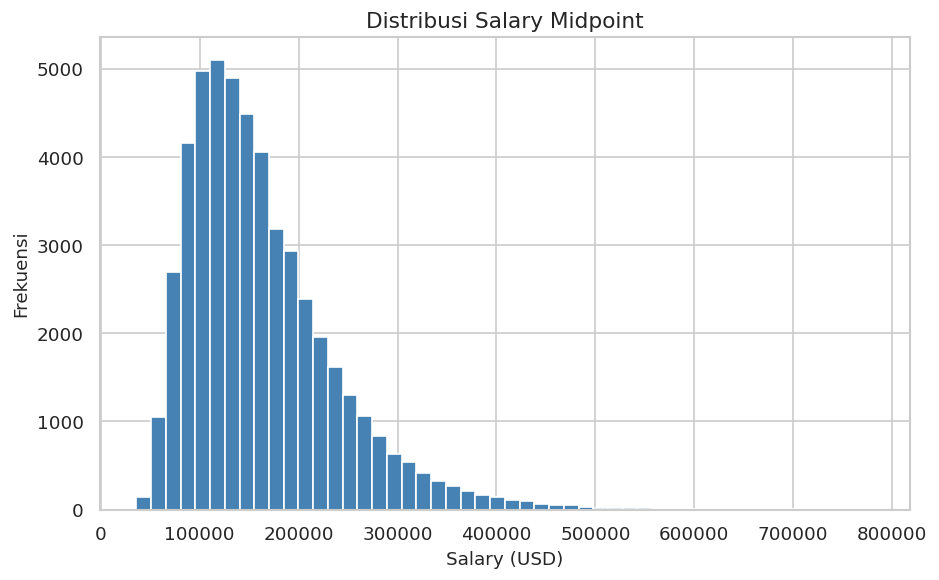


 Insghit Salary:
  • Mean  :    162,575
  • Median:    147,000
  • Std   :     74,156
  • Min   :     36,000
  • Max   :    781,000


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['salary_midpoint'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribusi Salary Midpoint')
ax.set_xlabel('Salary (USD)')
ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print("\n Insghit Salary:")
print(f"  • Mean  : {df['salary_midpoint'].mean():>10,.0f}")
print(f"  • Median: {df['salary_midpoint'].median():>10,.0f}")
print(f"  • Std   : {df['salary_midpoint'].std():>10,.0f}")
print(f"  • Min   : {df['salary_midpoint'].min():>10,.0f}")
print(f"  • Max   : {df['salary_midpoint'].max():>10,.0f}")

**Insight:**
* Rata-rata gaji (mean) berada di sekitar 162,575 USD, dengan median 147,000 USD, menunjukkan bahwa ada beberapa gaji yang lebih tinggi menarik rata-rata ke atas (distribusi cenderung condong ke kanan).
* Rentang gaji sangat luas, dari minimum 36,000 USD hingga maksimum 781,000 USD, dengan standar deviasi yang besar (74,156 USD) yang mengindikasikan variasi gaji yang signifikan.

## 4.9 Explorasi tren Salary

In [ ]:
tech_job_titles = [
    'Backend Developer', 'Cloud Architect', 'Software Engineer',
    'Senior Software Engineer', 'Data Engineer', 'Frontend Developer',
    'Cybersecurity Analyst', 'Machine Learning Engineer', 'UX Designer',
    'Data Analyst', 'Data Scientist', 'Research Scientist', 'DevOps Engineer'
]

# Filter Mid level dari experience level
mid_mask = df['experience_level'] == 'Mid (3-5 yrs)'
mid_df = df[mid_mask].copy()
mid_df['is_tech_derived'] = mid_df['job_title'].isin(tech_job_titles).astype(int)
mid_df['year_col'] = mid_df['year_eda']

salary_trend = mid_df.groupby(['year_col', 'is_tech_derived'])['salary_midpoint'].mean().unstack()
salary_trend.columns = ['Non-Tech', 'Tech']

print("Rata-Rata Salary per Tahun (Mid Level):")
print(salary_trend.applymap(lambda x: f"{x:,.0f}").to_string())

Rata-Rata Salary per Tahun (Mid Level):
         Non-Tech     Tech
year_col                  
2020      117,042  135,508
2021      119,242  139,474
2022      132,710  149,731
2023      129,904  156,019
2024      131,679  154,042


**Insight:**

Berdasarkan eksplorasi tren salary, baik non-tech maupun tech memiliki kenaikan tiap tahunnya, dan tech memiliki salary yang lebih tinggi dan kenaikan lebih agresif.

## 4.10 Explorasi Top Industri Berdasarkan Salary

In [ ]:
all_industries_avg_salary = (
    df.groupby('industry')['salary_midpoint'].mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\nRata-rata salary tiap industri:")
print(all_industries_avg_salary.to_string(index=False, formatters={'salary_midpoint': '{:,.0f}'.format}))


Rata-rata salary tiap industri:
     industry salary_midpoint
   E-commerce         164,130
Manufacturing         163,859
      Finance         163,465
   Healthcare         162,677
   Government         162,489
    Education         162,478
    Logistics         162,461
         Tech         162,081
        Media         162,062
   Consulting         161,504
       Retail         161,129


**Insight:**

* Terdapat 5 industri yang masuk dalam peringkat 5 besar dengan rata-rata gaji tertinggi, yaitu E-commerce, Finance, Healthcare, Logistics, dan Media.
* E-commerce memimpin dengan rata-rata gaji tertinggi sebesar 164,130 USD

## 4.11 Explorasi Top Job Title Berdasarkan Salary

In [ ]:
all_job_title_avg_salary = (
    df.groupby('job_title')['salary_midpoint'].mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\nRata-rata salary tiap job title:")
print(all_job_title_avg_salary.to_string(index=False, formatters={'salary_midpoint': '{:,.0f}'.format}))


Rata-rata salary tiap job title:
                job_title salary_midpoint
 Senior Software Engineer         236,322
     Quantitative Analyst         227,372
          Cloud Architect         220,605
Machine Learning Engineer         197,990
          Product Manager         185,954
       Research Scientist         183,520
            Data Engineer         175,354
          DevOps Engineer         173,996
        Software Engineer         173,004
        Backend Developer         158,911
           Data Scientist         158,734
    Cybersecurity Analyst         153,158
       Frontend Developer         144,426
              UX Designer         136,099
        Marketing Manager         129,522
       Operations Manager         126,982
        Financial Analyst         122,064
         Business Analyst         121,937
             Data Analyst         115,060
               HR Manager         105,423


**Insight:**
* Terdapat 5 Job Title yang masuk dalam peringkat 5 besar dengan rata-rata gaji tertinggi, yaitu Senior Software Engineer, Quantitative Analyst, Cloud Architect, Machine Learning Engineer, dan Product Manager.
* Senior Software Engineer memimpin dengan rata-rata gaji tertinggi sebesar 236,322 USD

## 4.12 Explorasi Top skill Berdasarkan Salary

In [ ]:
# First, create a mapping of job_id to skills, handling multiple skills per job
skills_data = df[['job_id', 'skills_required', 'salary_midpoint']].copy()
skills_data['skills_required'] = skills_data['skills_required'].str.split('|')
skills_data_exploded = skills_data.explode('skills_required')
skills_data_exploded['skills_required'] = skills_data_exploded['skills_required'].str.strip()

# Calculate the average salary for each skill
skill_avg_salary = skills_data_exploded.groupby('skills_required')['salary_midpoint'].mean().sort_values(ascending=False).round(0)

print("Top 20 Keahlian Teknis dengan Rata-rata Gaji Tertinggi:")
print(skill_avg_salary.head(20).apply(lambda x: f"{x:,.0f}"))

Top 20 Keahlian Teknis dengan Rata-rata Gaji Tertinggi:
skills_required
System Design        235,821
Microservices        229,224
Derivatives          228,766
C++                  228,503
Risk Management      226,074
Cost Optimization    224,857
Azure                221,485
Security             220,510
GCP                  220,478
CI/CD                204,720
Kubernetes           200,887
MLOps                199,427
PyTorch              197,427
Terraform            194,546
AWS                  190,433
Java                 189,608
Docker               189,157
R                    189,143
Product Strategy     186,435
Roadmapping          184,999
Name: salary_midpoint, dtype: object


**Insight:**
* Terdapat 5 Skill yang masuk dalam peringkat 5 besar dengan rata-rata gaji tertinggi, yaitu System Design, Microservice, Derivatives, C++ dan Risk Management.
* System Design memimpin dengan rata-rata gaji tertinggi sebesar 235,821 USD

# **5. Visualization & Explanatory Analysis**

*  Pada tahap ini, kita akan menjawab pertanyaan bisnis utama dengan memvisualisasikan temuan-temuan kunci yang telah ditemukan pada tahap EDA. Fokus kita adalah memberikan penjelasan yang mendalam (explanatory) di balik setiap grafik yang dihasilkan.

* Tahap ini akan menggunakan kolom `year_eda` dan `seniority_eda`
yang diekstrak sebelum proses drop, sehingga tidak terjadi `KeyError`.

### Pertanyaan 1: **Bagaimana tren pertumbuhan rata-rata salary Tech vs Non-Tech pada level Mid dari tahun ke tahun (2020–2024)?**

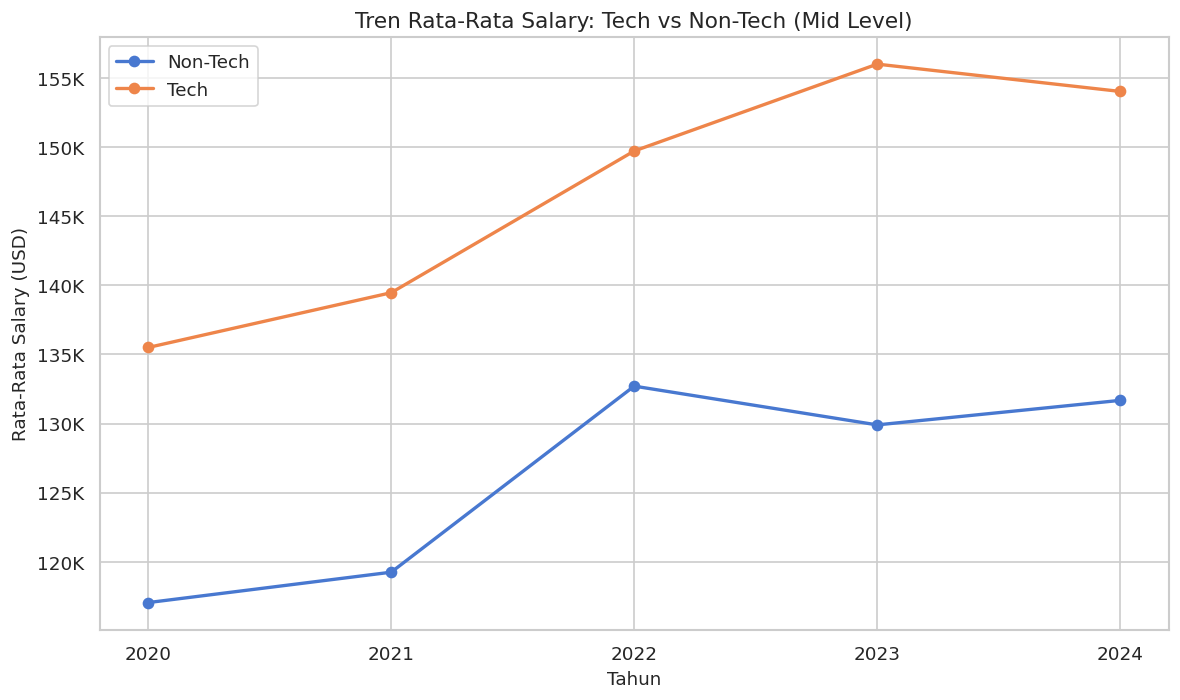

Rata-Rata Salary per Tahun (Mid Level):
Non-Tech    Tech
 117,042 135,508
 119,242 139,474
 132,710 149,731
 129,904 156,019
 131,679 154,042

YoY Growth (%):
          Tech YoY %  Non-Tech YoY %
year_col                            
2020             NaN             NaN
2021            2.93            1.88
2022            7.35           11.29
2023            4.20           -2.11
2024           -1.27            1.37

 • Rata-rata pertumbuhan tahunan Tech   : 3.30%
 • Rata-rata pertumbuhan tahunan Non-Tech: 3.11%


In [ ]:
tech_job_titles = [
    'Backend Developer', 'Cloud Architect', 'Software Engineer',
    'Senior Software Engineer', 'Data Engineer', 'Frontend Developer',
    'Cybersecurity Analyst', 'Machine Learning Engineer', 'UX Designer',
    'Data Analyst', 'Data Scientist', 'Research Scientist', 'DevOps Engineer'
]

# Filter Mid level dari seniority_eda
mid_mask = df['seniority_eda'] == 'Mid'
mid_df = df[mid_mask].copy()
mid_df['is_tech_derived'] = mid_df['job_title'].isin(tech_job_titles).astype(int)
mid_df['year_col'] = mid_df['year_eda']

salary_trend = mid_df.groupby(['year_col', 'is_tech_derived'])['salary_midpoint'].mean().unstack().round(0)
salary_trend.columns = ['Non-Tech', 'Tech']

# Hitung pertumbuhan YoY
yoy_tech    = salary_trend['Tech'].pct_change() * 100
yoy_nontech = salary_trend['Non-Tech'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 6))

salary_trend.plot(marker='o', ax=ax, linewidth=2)
ax.set_title('Tren Rata-Rata Salary: Tech vs Non-Tech (Mid Level)')
ax.set_xlabel('Tahun')
ax.set_ylabel('Rata-Rata Salary (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()

plt.tight_layout()
plt.show()

print("Rata-Rata Salary per Tahun (Mid Level):")
print(salary_trend.to_string(index=False, formatters={'Non-Tech': '{:,.0f}'.format,
                                                      'Tech': '{:,.0f}'.format}))
print("\nYoY Growth (%):")
result = pd.DataFrame({'Tech YoY %': yoy_tech.round(2), 'Non-Tech YoY %': yoy_nontech.round(2)})
print(result.to_string())

avg_tech_growth = yoy_tech.dropna().mean()
avg_nontech_growth = yoy_nontech.dropna().mean()
print(f"\n • Rata-rata pertumbuhan tahunan Tech   : {avg_tech_growth:.2f}%")
print(f" • Rata-rata pertumbuhan tahunan Non-Tech: {avg_nontech_growth:.2f}%")

**Interpretasi Data:**
* Tech selalu lebih tinggi dari Non-Tech: Sepanjang 2020–2024, salary Tech konsisten lebih tinggi dibandingkan Non-Tech di setiap tahunnya. Gap terkecil terjadi di 2022 sebesar 17,021 USD dan terbesar di 2023 sebesar 26,115 USD, menunjukkan bahwa keunggulan salary Tech semakin melebar seiring waktu.
* Tren kenaikan Tech lebih agresif (2020–2023): Tech tumbuh dari 135,508 USD → 156,019 USD dalam 3 tahun (2020–2023), dengan puncak pertumbuhan di 2022 (YoY +7.35%). Ini mencerminkan tingginya permintaan talent tech pasca pandemi yang mendorong perusahaan bersaing menawarkan kompensasi lebih tinggi.
* Non-Tech mengalami lonjakan besar di 2022: Non-Tech justru mencatat YoY growth tertinggi di 2022 (+11.30%) bahkan melampaui pertumbuhan Tech di tahun yang sama (+7.35%). Ini mengindikasikan bahwa perusahaan Non-Tech mulai menaikkan standar salary secara agresif di 2022, kemungkinan untuk bersaing menarik talent di tengah ketatnya pasar kerja pasca pandemi.

### Pertanyaan 2: **Apa 5 industri dengan rata-rata gaji tertinggi secara konsisten setiap tahun (2020–2024)?**

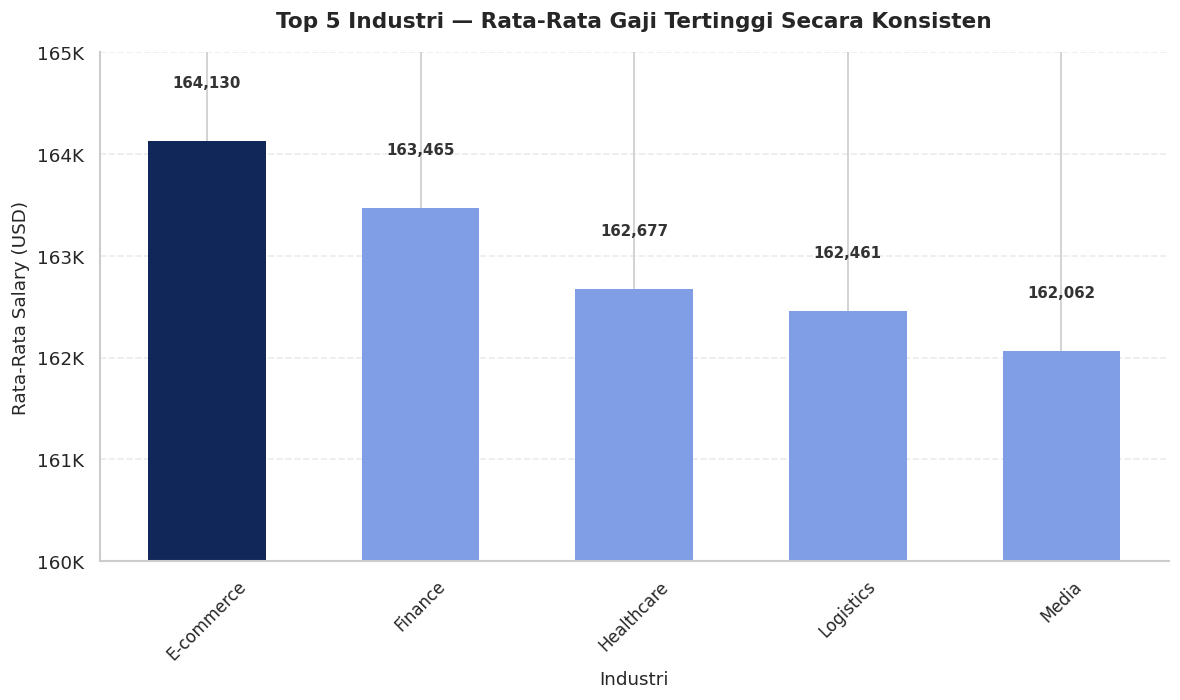

Konsistensi masuk Top-5 per tahun:
industry
E-commerce       3
Finance          3
Logistics        3
Healthcare       3
Media            3
Manufacturing    3
Education        2
Government       2

Rata-rata salary Top-5 industri konsisten:
  industry salary_midpoint
E-commerce         164,130
   Finance         163,465
Healthcare         162,677
 Logistics         162,461
     Media         162,062

KESIMPULAN:
  • Industri E-commerce memimpin dengan rata-rata 164,130 USD


In [ ]:
industry_yearly = df.groupby(['year_eda', 'industry'])['salary_midpoint'].mean().reset_index()
industry_yearly['rank'] = industry_yearly.groupby('year_eda')['salary_midpoint'].rank(
    ascending=False, method='first')
top5_yearly = industry_yearly[industry_yearly['rank'] <= 5]

consistency = top5_yearly['industry'].value_counts()
consistent_top5 = consistency[consistency >= 3].head(5).index.tolist()

top5_avg = (
    df[df['industry'].isin(consistent_top5)]
    .groupby('industry')['salary_midpoint'].mean().round()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

# Define custom colors
highest_salary_color = '#122759' # Dark blue for the highest
other_industries_color = '#809EE5' # Lighter blue for others

bar_colors = [highest_salary_color] + [other_industries_color] * (len(top5_avg) - 1)

bars = ax.bar(top5_avg['industry'], top5_avg['salary_midpoint'],
                    color=bar_colors, edgecolor='none', width=0.55)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
                 h + 500,
                 f'{h:,.0f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333')

ax.set_title('Top 5 Industri — Rata-Rata Gaji Tertinggi Secara Konsisten',
                  fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Industri', fontsize=11)
ax.set_ylabel('Rata-Rata Salary (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylim(160000, 165000)

plt.tight_layout()
plt.show()

print("Konsistensi masuk Top-5 per tahun:")
print(consistency.head(8).to_string())
print("\nRata-rata salary Top-5 industri konsisten:")
print(top5_avg.to_string(index=False, formatters={'salary_midpoint': '{:,.0f}'.format}))
print("\nKESIMPULAN:")
print(f"  • Industri {top5_avg.iloc[0]['industry']} memimpin dengan rata-rata {top5_avg.iloc[0]['salary_midpoint']:,.0f} USD")

**Interpretasi Data:**
* E-commerce memimpin gaji tertinggI dengan rata-rata 164,130 USD, diikuti Finance dengan rata-rata 163,465 USD, keduanya mencerminkan tingginya permintaan talenta digital dan finansial.
* Rentang antara peringkat 1 (E-commerce) dan 5 (Media) hanya sekitar 2,000 USD, menunjukkan kelima industri ini secara kompetitif menawarkan kompensasi yang setara.
* Seluruh Top 5 industri masuk peringkat tertinggi secara konsisten selama 3 tahun berturut-turut, mengindikasikan stabilitas pasar kerja di sektor-sektor tersebut.

### Pertanyaan 3: **Apa 5 Job Title dengan rata-rata gaji tertinggi di seluruh periode data?**

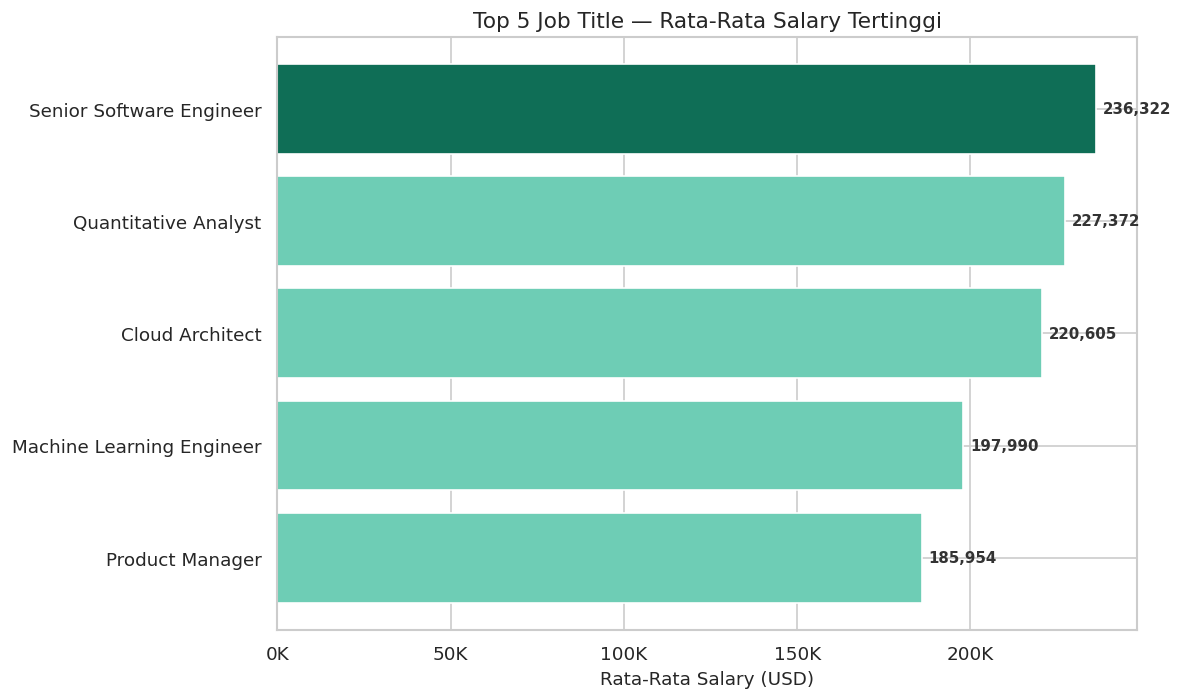

Detail Top 5 Job Title:
                job_title rata_rata  median  jumlah_posting
 Senior Software Engineer   236,322 218,000            2550
     Quantitative Analyst   227,372 211,000            2582
          Cloud Architect   220,605 202,000            2500
Machine Learning Engineer   197,990 182,000            2536
          Product Manager   185,954 173,000            2442

KESIMPULAN:
  • Senior Software Engineer memimpin dengan rata-rata 236,322 USD


In [ ]:
job_title_stats = df.groupby('job_title')['salary_midpoint'].agg(
    rata_rata='mean', median='median', jumlah_posting='count'
).sort_values('rata_rata', ascending=False)

top5_jt = job_title_stats.head(5).reset_index().round(0)

fig, ax = plt.subplots(figsize=(10, 6))

# Define custom colors for the bar chart
highest_salary_color = '#0F6E56' # Dark blue for the highest salary
other_job_titles_color = '#6ECDB5' # Lighter blue for others

bar_colors_barh = [other_job_titles_color] * (len(top5_jt) - 1) + [highest_salary_color]

bars = ax.barh(top5_jt['job_title'][::-1], top5_jt['rata_rata'][::-1], color=bar_colors_barh)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 2000,
                 bar.get_y() + bar.get_height()/2,
                 f'{w:,.0f}',
                 ha='left', va='center', fontsize=9, fontweight='bold', color='#333')

ax.set_title('Top 5 Job Title — Rata-Rata Salary Tertinggi')
ax.set_xlabel('Rata-Rata Salary (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

print("Detail Top 5 Job Title:")
print(top5_jt[['job_title', 'rata_rata', 'median', 'jumlah_posting']].to_string(index=False, formatters={'rata_rata': '{:,.0f}'.format,
                                                                                                         'median': '{:,.0f}'.format}))

print("\nKESIMPULAN:")
print(f"  • {top5_jt.iloc[0]['job_title']} memimpin dengan rata-rata {top5_jt.iloc[0]['rata_rata']:,.0f} USD")

**Interpretasi Data:**
* Dengan rata-rata 236,322 USD dan median 218,000 USD, posisi Senior Software Engineer menjadi yang paling tinggi gajinya, mencerminkan tingginya nilai senioritas di bidang rekayasa perangkat lunak.
* Quantitative Analyst (227,372 USD), Cloud Architect (220,605 USD), dan Machine Learning Engineer (197,990 USD) membuktikan bahwa keahlian berbasis data, cloud, dan AI sangat dihargai di pasar kerja saat ini.
* Keempat posisi memiliki jumlah posting antara 2.442–2.582, menunjukkan permintaan yang tinggi dan stabil untuk seluruh job title tersebut, bukan hanya untuk satu peran saja.

### Pertanyaan 4: **Apa 10 keahlian teknis dengan frekuensi permintaan tertinggi di pasar kerja?**

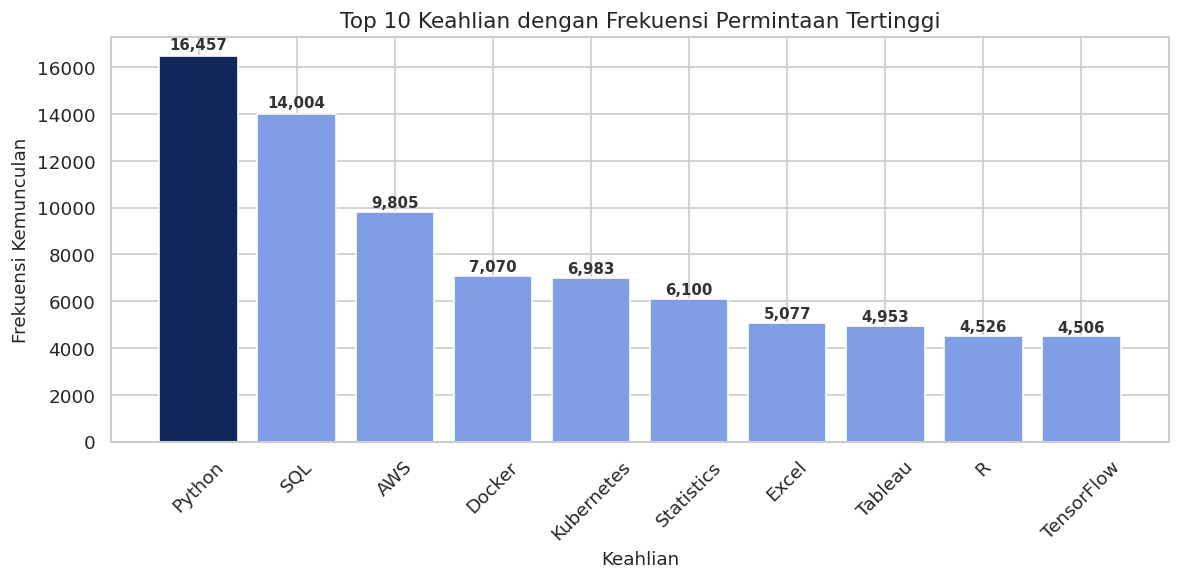

Top 10 Skills Paling Dicari:
   1. Python                        : 16,457 (32.9% dari semua postingan)
   2. SQL                           : 14,004 (28.0% dari semua postingan)
   3. AWS                           : 9,805 (19.6% dari semua postingan)
   4. Docker                        : 7,070 (14.1% dari semua postingan)
   5. Kubernetes                    : 6,983 (14.0% dari semua postingan)
   6. Statistics                    : 6,100 (12.2% dari semua postingan)
   7. Excel                         : 5,077 (10.2% dari semua postingan)
   8. Tableau                       : 4,953 (9.9% dari semua postingan)
   9. R                             : 4,526 (9.1% dari semua postingan)
  10. TensorFlow                    : 4,506 (9.0% dari semua postingan)

KESIMPULAN:
  • Python adalah skill paling banyak diminta (16,457 postingan)


In [ ]:
top10_skills_freq = skill_counts.head(10).sort_values(ascending=False) # Ensure consistent sorting for vertical plot

fig, ax = plt.subplots(figsize=(10, 5))

# Define custom colors for the bar chart
highest_skill_color = '#122759' # Dark blue for the highest frequency skill
other_skills_color = '#809EE5' # Lighter blue for others

# Create a list of colors based on the order in top10_skills_freq
# The highest frequency skill is the first one after sorting descending
bar_colors_vertical = [highest_skill_color] + [other_skills_color] * (len(top10_skills_freq) - 1)

bars = ax.bar(top10_skills_freq.index, top10_skills_freq.values,
               color=bar_colors_vertical)

ax.set_title('Top 10 Keahlian dengan Frekuensi Permintaan Tertinggi')
ax.set_xlabel('Keahlian')
ax.set_ylabel('Frekuensi Kemunculan')

# Add annotations to the vertical bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, # Center text horizontally above the bar
                 h + (h * 0.01), # Add 1% of bar height as offset
                 f'{h:,}', # Display the height value
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333')

ax.tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

print("Top 10 Skills Paling Dicari:")
for i, (skill, freq) in enumerate(top10_skills_freq.items(), 1):
    pct = freq / len(df) * 100
    print(f"  {i:>2}. {skill:<30}: {freq:,} ({pct:.1f}% dari semua postingan)")
print("\nKESIMPULAN:")
print(f"  • {top10_skills_freq.index[0]} adalah skill paling banyak diminta ({top10_skills_freq.iloc[0]:,} postingan)")

**Interpretasi Data:**
*  Python (32,9%) dan SQL (28,0%) jauh melampaui skill lainnya, menjadikannya keahlian paling fundamental yang wajib dikuasai oleh siapapun yang ingin bersaing di industri teknologi dan data.
* AWS (19,6%), Docker (14,1%), dan Kubernetes (14,0%) masuk Top 5, mencerminkan tingginya adopsi infrastruktur cloud dan teknologi container di dunia kerja saat ini.
* Statistics, Excel, Tableau, R, dan TensorFlow melengkapi Top 10 dengan kisaran 9–12%, menunjukkan bahwa kemampuan analisis data dan machine learning tetap menjadi kompetensi yang konsisten dicari perusahaan.

### Pertanyaan 5: **Apa 10 keahlian teknis yang memberikan rata-rata penawaran gaji tertinggi?**

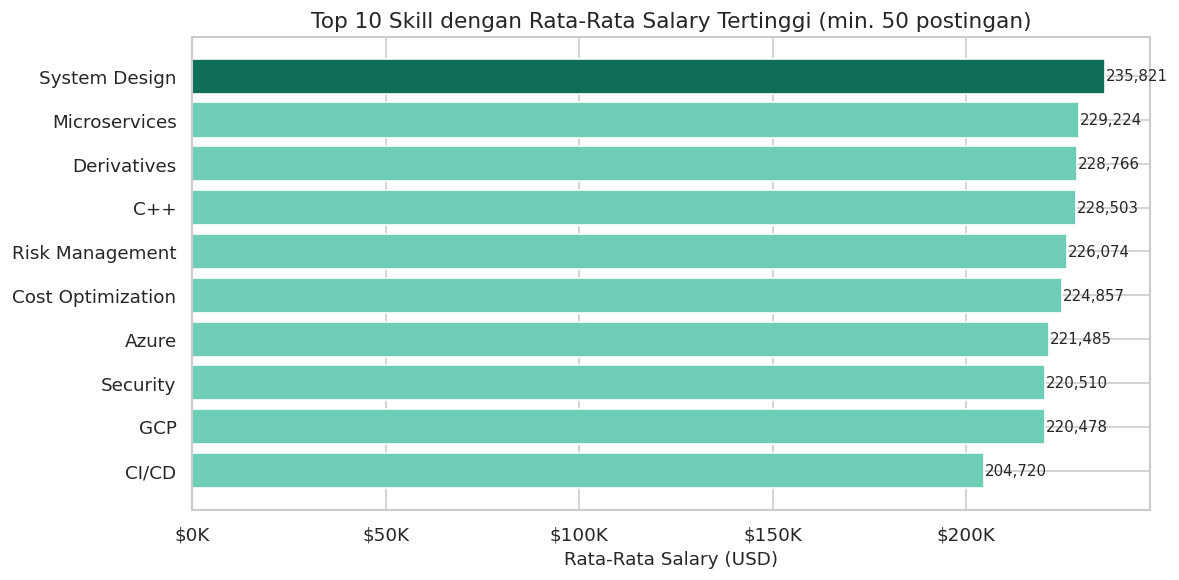

Top 10 Skills dengan Rata-Rata Salary Tertinggi:
  skills_required rata_rata  jumlah
    System Design   235,821    1404
    Microservices   229,224    2838
      Derivatives   228,766    1422
              C++   228,503    1415
  Risk Management   226,074    1442
Cost Optimization   224,857    1392
            Azure   221,485    1380
         Security   220,510    1410
              GCP   220,478    1404
            CI/CD   204,720    2859

KESIMPULAN:
  • Skill System Design memberi rata-rata salary tertinggi ($235,821)


In [ ]:
skills_salary = df[['skills_required', 'salary_midpoint']].copy()
skills_salary['skills_required'] = skills_salary['skills_required'].str.split('|')
skills_salary_exploded = skills_salary.explode('skills_required')
skills_salary_exploded['skills_required'] = skills_salary_exploded['skills_required'].str.strip()

skill_salary_stats = skills_salary_exploded.groupby('skills_required')['salary_midpoint'].agg(
    rata_rata='mean', jumlah='count').sort_values('rata_rata', ascending=False)

# Filter min 50 kemunculan agar representatif
skill_salary_stats_filtered = skill_salary_stats[skill_salary_stats['jumlah'] >= 50]
top10_sal = skill_salary_stats_filtered.head(10).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

# Define custom colors for the bar chart
highest_salary_color = '#0F6E56' # Dark blue for the highest salary
other_skills_color = '#6ECDB5' # Lighter blue for others

# Create a list of colors based on the order in top10_sal.
# Since barh reverses the order (due to [::-1]), the highest salary (which is top10_sal.iloc[0])
# will be the LAST bar plotted, so its color needs to be at the end of the bar_colors list.
bar_colors = [other_skills_color] * (len(top10_sal) - 1) + [highest_salary_color]

bars = ax.barh(top10_sal['skills_required'][::-1], top10_sal['rata_rata'][::-1],
               color=bar_colors)
ax.set_title('Top 10 Skill dengan Rata-Rata Salary Tertinggi (min. 50 postingan)')
ax.set_xlabel('Rata-Rata Salary (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height()/2, f'{w:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Top 10 Skills dengan Rata-Rata Salary Tertinggi:")
print(top10_sal[['skills_required', 'rata_rata', 'jumlah']].to_string(index=False,formatters={'rata_rata': '{:,.0f}'.format}))
print("\nKESIMPULAN:")
print(f"  • Skill {top10_sal.iloc[0]['skills_required']} memberi rata-rata salary tertinggi (${top10_sal.iloc[0]['rata_rata']:,.0f})")

**Interpretasi Data:**
* System Design (235,821 USD) dan Microservices (229,224 USD) memimpin, menunjukkan bahwa kemampuan merancang sistem skala besar sangat bernilai tinggi dibanding skill teknis lainnya.
* Derivatives, C++, Risk Management, dan Cost Optimization masuk Top 6 dengan gaji 224K USD hingga 229K USD, mencerminkan bahwa perpaduan keahlian teknis dan finansial/bisnis sangat diapresiasi pasar.
* Azure (221,485 USD), Security (220,510 USD), GCP (220,478 USD), dan CI/CD (204,720 USD) melengkapi Top 10, membuktikan bahwa skill infrastruktur cloud dan keamanan konsisten menawarkan kompensasi yang tinggi meski bukan yang tertinggi.

# **6. Conclusion & Rekomendasi**

## 6.1 Conclusion

- **Conclusion Pertanyaan 1: Bagaimana tren pertumbuhan rata-rata salary Tech vs Non-Tech pada level Mid dari tahun ke tahun (2020–2024)?**
  
  Meskipun sektor Tech konsisten mendominasi nominal gaji sepanjang 2020–2024 dengan puncak kesenjangan di tahun 2023, dinamika pertumbuhannya menunjukkan pergeseran lanskap pasar yang signifikan. Kompetisi talent pasca-pandemi sempat memaksa sektor Non-Tech beradaptasi secara agresif melalui lonjakan kenaikan gaji pada 2022 (+11.30%) demi mempertahankan daya saing. Namun, memasuki 2024, tren tersebut berbalik arah; ketika sektor Tech mulai memasuki fase koreksi pasar atau tech winter (terkontraksi -1.27%), sektor Non-Tech justru tampil lebih resilien dengan kembali mencetak pertumbuhan positif (+1.37%), menandakan transisi dari era pertumbuhan agresif teknologi menuju fase stabilitas kompensasi yang lebih kuat di industri konvensional.
- **Conclusion Pertanyaan 2: Apa 5 industri dengan rata-rata gaji tertinggi secara konsisten setiap tahun (2020–2024)?**

  Meskipun sektor E-commerce dan Finance memimpin nominal gaji rata-rata tertinggi, rentang kompensasi yang sangat tipis hanya berselisih sekitar 2.000 USD di antara seluruh lima industri teratas—menunjukkan persaingan akuisisi talenta yang sangat ketat dan kompetitif. Di balik angka tersebut, data konsistensi historis (2020–2024) justru mengungkap rotasi pasar yang sangat dinamis. Fakta bahwa tidak ada satu pun industri yang mampu mempertahankan dominasi Top-5 secara absolut selama lima tahun penuh (maksimal hanya bertahan selama tiga tahun) mengindikasikan bahwa peta persaingan kompensasi terus bergeser, menuntut para profesional untuk tetap adaptif terhadap fluktuasi tren di berbagai sektor ekonomi.

- **Conclusion Pertanyaan 3: Apa 5 Job Title dengan rata-rata gaji tertinggi di seluruh periode data?**

  Dominasi posisi Senior Software Engineer (236.322 USD) menegaskan besarnya premi pasar terhadap senioritas teknis, yang kemudian diiringi secara ketat oleh peran spesialisasi tinggi seperti Quantitative Analyst, Cloud Architect, dan Machine Learning Engineer sebagai pilar utama ekosistem digital berbasis data, cloud, dan AI. Fakta bahwa tingginya nilai kompensasi ini berjalan selaras dengan volume posting kerja yang sangat konsisten di kisaran 2.442 hingga 2.582 lowongan memberikan bukti krusial bahwa angka tersebut bukanlah anomali, melainkan representasi dari permintaan pasar riil yang masif dan stabil. Keselarasan antara kompensasi premium dan kepastian demand ini menegaskan bahwa penguasaan keahlian teknologi tingkat lanjut memberikan nilai tawar ekonomi yang sangat kuat serta fondasi yang menjanjikan dalam pemetaan karier jangka panjang.

- **Conclusion Pertanyaan 4: Apa 10 keahlian teknis dengan frekuensi permintaan tertinggi di pasar kerja?**

  Dominasi Python (32,9%) dan SQL (28,0%) menegaskan bahwa kedua kompetensi ini bukan lagi sekadar nilai tambah, melainkan fondasi fundamental tak tergantikan yang wajib dikuasai untuk bersaing di industri teknologi. Lebih jauh, komposisi Top-10 keahlian ini secara brilian merepresentasikan kerangka end-to-end workflow dari sebuah ekosistem teknologi modern, di mana fondasi ekstraksi dan manipulasi data (SQL, Python) berjalan berdampingan dengan ketajaman analitik serta machine learning (Statistics, Excel, Tableau, R, TensorFlow), dan bermuara pada penguasaan infrastruktur deployment berskala besar (AWS, Docker, Kubernetes). Hal ini menyimpulkan bahwa pasar kerja saat ini tidak lagi sekadar mencari talenta yang hanya jago di satu tools spesifik, melainkan mencari mereka yang memahami gambaran besar sebuah proyek, dari sekadar wujud data mentah hingga menjadi solusi nyata yang siap beroperasi secara masif.

- **Conclusion Pertanyaan 5:  Apa 10 keahlian teknis yang memberikan rata-rata penawaran gaji tertinggi?**

  Daftar keahlian dengan kompensasi tertinggi ini menegaskan bahwa pasar kerja memprioritaskan pemikiran arsitektural skala besar dan spesialisasi lintas disiplin di atas kemampuan teknis fundamental. Dominasi System Design dan Microservices di posisi puncak membuktikan tingginya valuasi terhadap peran yang mampu merancang infrastruktur scalable, sementara kemunculan C++, Derivatives, dan Risk Management menyoroti betapa menggiurkannya ceruk pasar premium yang menggabungkan ketajaman komputasi dengan keahlian spesifik di domain finansial. Namun, temuan paling strategis justru terletak pada keseimbangan antara kompensasi dan volume permintaan pasar; di mana keahlian operasional seperti Microservices dan CI/CD tidak hanya menawarkan gaji premium di atas 200.000 USD, tetapi juga mencatatkan volume lowongan (ketersediaan pekerjaan) hampir dua kali lipat lebih masif dibandingkan skill elite lainnya, menjadikannya investasi kompetensi tingkat lanjut yang paling tangguh dan menguntungkan untuk dieksekusi oleh para profesional


## 6.2 Rekomendasi

**1. Kuasai End-to-End Workflow dengan Fokus pada Fase Deployment.**

Jangan terjebak menjadi spesialis yang hanya menguasai satu alat (tools) terisolasi, seperti hanya fokus pada pengolahan data mentah atau pemodelan saja. Pastikan fondasi dasar (Python & SQL) sudah matang, lalu segera tingkatkan kompetensi ke arah arsitektur sistem dan operasionalisasi (Cloud, Microservices, dan CI/CD). Strategi ini sangat krusial karena keterampilan di fase deployment berada di titik keseimbangan paling sempurna di pasar kerja saat ini menawarkan kompensasi yang tinggi sekaligus memiliki volume lowongan kerja dua kali lipat lebih masif dibanding skill elite lainnya.

**2. Alihkan Target Karier ke Industri Non-Tech Premium yang Resilien.**

Di tengah fase efisiensi massal (tech winter) yang sedang melanda perusahaan teknologi murni seperti E-commerce, perluas jangkauan radar karier ke sektor konvensional yang sedang gencar melakukan digitalisasi dan otomatisasi, seperti Finance, Healthcare, atau Manufaktur Modern. Sektor-sektor ini terbukti memiliki resiliensi pertumbuhan yang lebih stabil di tahun 2024 (+1.37%) dan menawarkan standar gaji yang sangat kompetitif dengan selisih yang sangat tipis (hanya berkisar $2.000) dari industri teknologi tertinggi.

**3. Bidik Peran Spesialisasi Tinggi dengan Permintaan Pasar yang Pasti.**

Pilihlah jalur karier jangka panjang pada posisi spesifik yang memiliki nilai tawar ekonomi tinggi namun didukung oleh volume lowongan yang riil dan stabil, seperti Machine Learning Engineer atau Cloud Architect. Data membuktikan bahwa posisi spesialisasi tinggi ini secara konsisten membuka hingga lebih dari 2.500 lowongan kerja, yang berarti angka kompensasi tinggi mereka bukanlah anomali pasar dari posisi langka, melainkan mencerminkan kebutuhan industri yang nyata, masif, dan berkelanjutan.

# **7. Feature Importance**

Feature importance dilakukan untuk mengukur seberapa besar kontribusi setiap fitur terhadap prediksi job_title. Metode yang digunakan adalah Random Forest dengan pendekatan Mean Decrease in Impurity (MDI).

In [ ]:
df_imp = df.copy()

# Encode skills_required → MultiLabelBinarizer
df_imp['skills_list'] = df_imp['skills_required'].apply(
    lambda x: [s.strip() for s in str(x).split('|') if s.strip()])
mlb_fi_skills = MultiLabelBinarizer()
skills_fi = pd.DataFrame(
    mlb_fi_skills.fit_transform(df_imp['skills_list']),
    columns=[f'skill_{s}' for s in mlb_fi_skills.classes_],
    index=df_imp.index
)
print(f"Shape skills matrix  : {skills_fi.shape}")
print(f"Skill list           : {list(mlb_fi_skills.classes_)}\n")

# Encode education_background → MultiLabelBinarizer
df_imp['edu_bg_list'] = df_imp['education_background'].apply(
    lambda x: [s.strip() for s in str(x).split('|') if s.strip()])
mlb_fi_edu = MultiLabelBinarizer()
edu_bg_fi = pd.DataFrame(
    mlb_fi_edu.fit_transform(df_imp['edu_bg_list']),
    columns=[f'edu_{s}' for s in mlb_fi_edu.classes_],
    index=df_imp.index
)
print(f"Shape edu matrix                   : { edu_bg_fi.shape}")
print(f"Education list                     : {list(mlb_fi_edu.classes_)}\n")

Shape skills matrix  : (50000, 82)
Skill list           : ['A/B Testing', 'AWS', 'Accounting', 'Adobe XD', 'Agile', 'Airflow', 'Analytics', 'Azure', 'Bloomberg', 'Budgeting', 'C++', 'CI/CD', 'CRM', 'Compensation', 'Compliance', 'Content Strategy', 'Cost Optimization', 'Data Analysis', 'Data Visualization', 'Derivatives', 'Design Thinking', 'Digital Marketing', 'Docker', 'ERP', 'Employment Law', 'Excel', 'FP&A', 'Figma', 'Financial Modeling', 'GCP', 'Git', 'Google Ads', 'HRIS', 'HTML/CSS', 'Incident Response', 'Java', 'JavaScript', 'Kafka', 'Kubernetes', 'Lean', 'Linux', 'MLOps', 'Machine Learning', 'Microservices', 'Network Security', 'Penetration Testing', 'Performance Management', 'PostgreSQL', 'Power BI', 'Process Improvement', 'Product Strategy', 'Prototyping', 'Publications', 'PyTorch', 'Python', 'R', 'REST APIs', 'React', 'Redis', 'Requirements Gathering', 'Research', 'Risk Management', 'Roadmapping', 'SEO', 'SIEM', 'SQL', 'Security', 'Six Sigma', 'Snowflake', 'Spark', 'Stakehold

In [ ]:
# Encode kolom kategorikal lain → OrdinalEncoder
cat_cols_fi = ['education_required', 'seniority_eda', 'work_type', 'industry']
ord_fi = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
cat_fi = pd.DataFrame(
    ord_fi.fit_transform(df_imp[cat_cols_fi]),
    columns=cat_cols_fi,
    index=df_imp.index
)

# Gabungkan semua fitur
X_fi = pd.concat([
    cat_fi,
    df_imp[['min_GPA_requirement', 'salary_midpoint']].reset_index(drop=True),
    skills_fi.reset_index(drop=True),
    edu_bg_fi.reset_index(drop=True)
], axis=1)

print(f"\nTotal fitur setelah digabung : {X_fi.shape[1]}")
display(X_fi.head())


Total fitur setelah digabung : 101


,education_required,seniority_eda,work_type,industry,min_GPA_requirement,salary_midpoint,skill_A/B Testing,skill_AWS,skill_Accounting,skill_Adobe XD,...,edu_Electrical Engineering,edu_Industrial Engineering,edu_Informatics Engineering,edu_Information Systems,edu_Law,edu_Management,edu_Mathematics,edu_Mechanical Engineering,edu_Psychology,edu_Statistics
0,1.0,1.0,1.0,2.0,3.30,139000,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1
1,1.0,0.0,1.0,2.0,3.76,362000,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,5.0,4.0,1.0,0.0,3.59,136000,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1.0,4.0,0.0,5.0,3.48,306000,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,4.0,3.0,1.0,7.0,3.12,185000,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [ ]:
# Encode target
le_fi = LabelEncoder()
y_fi  = le_fi.fit_transform(df_imp['job_title'])

print("Mapping kelas:")
for i, cls in enumerate(le_fi.classes_):
    print(f"  {i:>2}: {cls}")

Mapping kelas:
   0: Backend Developer
   1: Business Analyst
   2: Cloud Architect
   3: Cybersecurity Analyst
   4: Data Analyst
   5: Data Engineer
   6: Data Scientist
   7: DevOps Engineer
   8: Financial Analyst
   9: Frontend Developer
  10: HR Manager
  11: Machine Learning Engineer
  12: Marketing Manager
  13: Operations Manager
  14: Product Manager
  15: Quantitative Analyst
  16: Research Scientist
  17: Senior Software Engineer
  18: Software Engineer
  19: UX Designer


In [ ]:
# Train Random Forest
X_train, X_test, y_train, y_test = train_test_split(
    X_fi.values, y_fi, test_size=0.2, random_state=42, stratify=y_fi)

rf_fi = RandomForestClassifier(n_estimators=200, min_samples_split=5,
                                random_state=42, n_jobs=-1)
rf_fi.fit(X_train, y_train)

y_pred = rf_fi.predict(X_test)
acc_fi = accuracy_score(y_test, rf_fi.predict(X_test))
print(f'Accuracy (Random Forest, sementara) : {acc_fi*100:.2f}%\n')
print(classification_report(y_test, y_pred, target_names=le_fi.classes_))

Accuracy (Random Forest, sementara) : 97.78%

                           precision    recall  f1-score   support

        Backend Developer       0.91      0.90      0.90       502
         Business Analyst       1.00      0.99      1.00       515
          Cloud Architect       1.00      1.00      1.00       500
    Cybersecurity Analyst       1.00      1.00      1.00       508
             Data Analyst       0.97      0.99      0.98       498
            Data Engineer       1.00      0.99      0.99       488
           Data Scientist       0.98      0.97      0.98       499
          DevOps Engineer       0.94      0.94      0.94       499
        Financial Analyst       1.00      1.00      1.00       497
       Frontend Developer       1.00      1.00      1.00       482
               HR Manager       1.00      1.00      1.00       488
Machine Learning Engineer       0.99      0.99      0.99       507
        Marketing Manager       1.00      1.00      1.00       503
       Operatio

In [ ]:
# Hitung importance & grouping kembali ke fitur asli
imp_raw = pd.Series(rf_fi.feature_importances_, index=X_fi.columns)

def group_feat(col):
    if col.startswith('skill_'): return 'skills_required'
    if col.startswith('edu_'):   return 'education_background'
    return col

imp_grouped = (imp_raw.groupby(imp_raw.index.map(group_feat))
               .sum().sort_values(ascending=False))
imp_pct = (imp_grouped / imp_grouped.sum() * 100).round(2)

# hasil Feature Importance
print('FEATURE IMPORTANCE — Fitur Original (skill digabung)')
for feat, pct in imp_pct.items():
    print(f'  {feat:<25} {pct:5.2f}%')

FEATURE IMPORTANCE — Fitur Original (skill digabung)
  skills_required           92.21%
  education_background       4.93%
  salary_midpoint            1.03%
  min_GPA_requirement        0.58%
  industry                   0.44%
  seniority_eda              0.30%
  education_required         0.29%
  work_type                  0.21%


**Insight:**
`skills_required` dan `education_background` adalah fitur paling dominan → wajib digunakan di model.

Berdasarkan hasil Feature importance dan pertimbangan konteks bisnis berikut merupakan fitur-fitur yang akan digunakan untuk tahap modeling:

| Kolom | Tipe |
|---|---|
| `skills_required` | Multi-label |
| `education_background` | Multi-label |
| `min_GPA_requirement` | Numerical |
| `education_required` | Ordinal Categorical |
| **Target: `job_title`** | Categorical |

In [ ]:
# Bersihkan variabel sementara
del df_imp, X_fi, y_fi, X_train, X_test, y_train, y_test, y_pred
del rf_fi, imp_raw, imp_grouped, skills_fi, edu_bg_fi, cat_fi
print('Variabel sementara telah dihapus.')

Variabel sementara telah dihapus.


# **8. Data Dictionary**

Data Dictionary mendokumentasikan setiap kolom yang digunakan dalam pemodelan, termasuk tipe, encoding, dan rentang nilainya.

In [ ]:
data_dict = {
    'Kolom': [
        'education_required',
        'skills_required', 'education_background', 'min_GPA_requirement', 'job_title'
    ],
    'Tipe Fitur': [
        'Ordinal Categorical',
        'Multi-label', 'Multi-label', 'Numerical', 'Target'
    ],
    'Encoding': [
        'OrdinalEncoder',
        'MultiLabelBinarizer', 'MultiLabelBinarizer', 'Passthrough', 'LabelEncoder'
    ],
    'Cardinality / Range': [
        df['education_required'].nunique(),
        len(skill_counts),
        len(edu_bg_counts),
        f"{df['min_GPA_requirement'].min():.2f} – {df['min_GPA_requirement'].max():.2f}",
        df['job_title'].nunique()
    ],
    'Deskripsi': [
        'Tingkat pendidikan minimum yang disyaratkan (High School → PhD)',
        'Daftar skill teknis yang dibutuhkan (multi-label, pipe-separated)',
        'Latar belakang pendidikan yang diharapkan (multi-label, pipe-separated)',
        'Nilai GPA minimum yang disyaratkan (0.0 – 4.0)',
        'Judul pekerjaan — variabel target prediksi (20 kelas)'
    ]
}

data_dictionary = pd.DataFrame(data_dict)
print("DATA DICTIONARY")
display(data_dictionary)

DATA DICTIONARY


,Kolom,Tipe Fitur,Encoding,Cardinality / Range,Deskripsi
0,education_required,Ordinal Categorical,OrdinalEncoder,6,Tingkat pendidikan minimum yang disyaratkan (H...
1,skills_required,Multi-label,MultiLabelBinarizer,82,Daftar skill teknis yang dibutuhkan (multi-lab...
2,education_background,Multi-label,MultiLabelBinarizer,13,Latar belakang pendidikan yang diharapkan (mul...
3,min_GPA_requirement,Numerical,Passthrough,3.00 – 3.80,Nilai GPA minimum yang disyaratkan (0.0 – 4.0)
4,job_title,Target,LabelEncoder,20,Judul pekerjaan — variabel target prediksi (20...


# **9. Feature Engineering**

Feature engineering dilakukan untuk menghasilkan fitur-fitur baru yang lebih informatif bagi model.
Strategi: ekstraksi fitur temporal dari `post_date`, dan pembuatan fitur agregat salary berbasis grup.

## 9.1 Fitur Temporal dari post_date

In [ ]:
df['post_month']     = df['post_date'].dt.month
df['post_quarter']   = df['post_date'].dt.quarter
df['post_year']      = df['post_date'].dt.year


## 9.2 Fitur Jumlah Skill (skill_count)

In [ ]:
df['skill_count'] = df['skills_required'].str.split('|').apply(len)

## 9.3 Fitur Jumlah Education Background

Fitur-fitur baru yang ditambahkan:
       post_month  post_quarter  post_year  skill_count  edu_bg_count  \
count    50000.00      50000.00   50000.00     50000.00      50000.00   
mean         6.53          2.51    2022.00         4.46          2.00   
std          3.45          1.12       1.42         1.11          0.82   
min          1.00          1.00    2020.00         3.00          1.00   
25%          4.00          2.00    2021.00         3.00          1.00   
50%          7.00          3.00    2022.00         4.00          2.00   
75%         10.00          4.00    2023.00         5.00          3.00   
max         12.00          4.00    2024.00         6.00          3.00   

       salary_vs_industry_mean  salary_vs_edu_mean  
count                 50000.00            50000.00  
mean                      0.00                0.00  
std                   74150.63            72361.71  
min                 -126477.75          -135427.87  
25%                  -53488.67           -

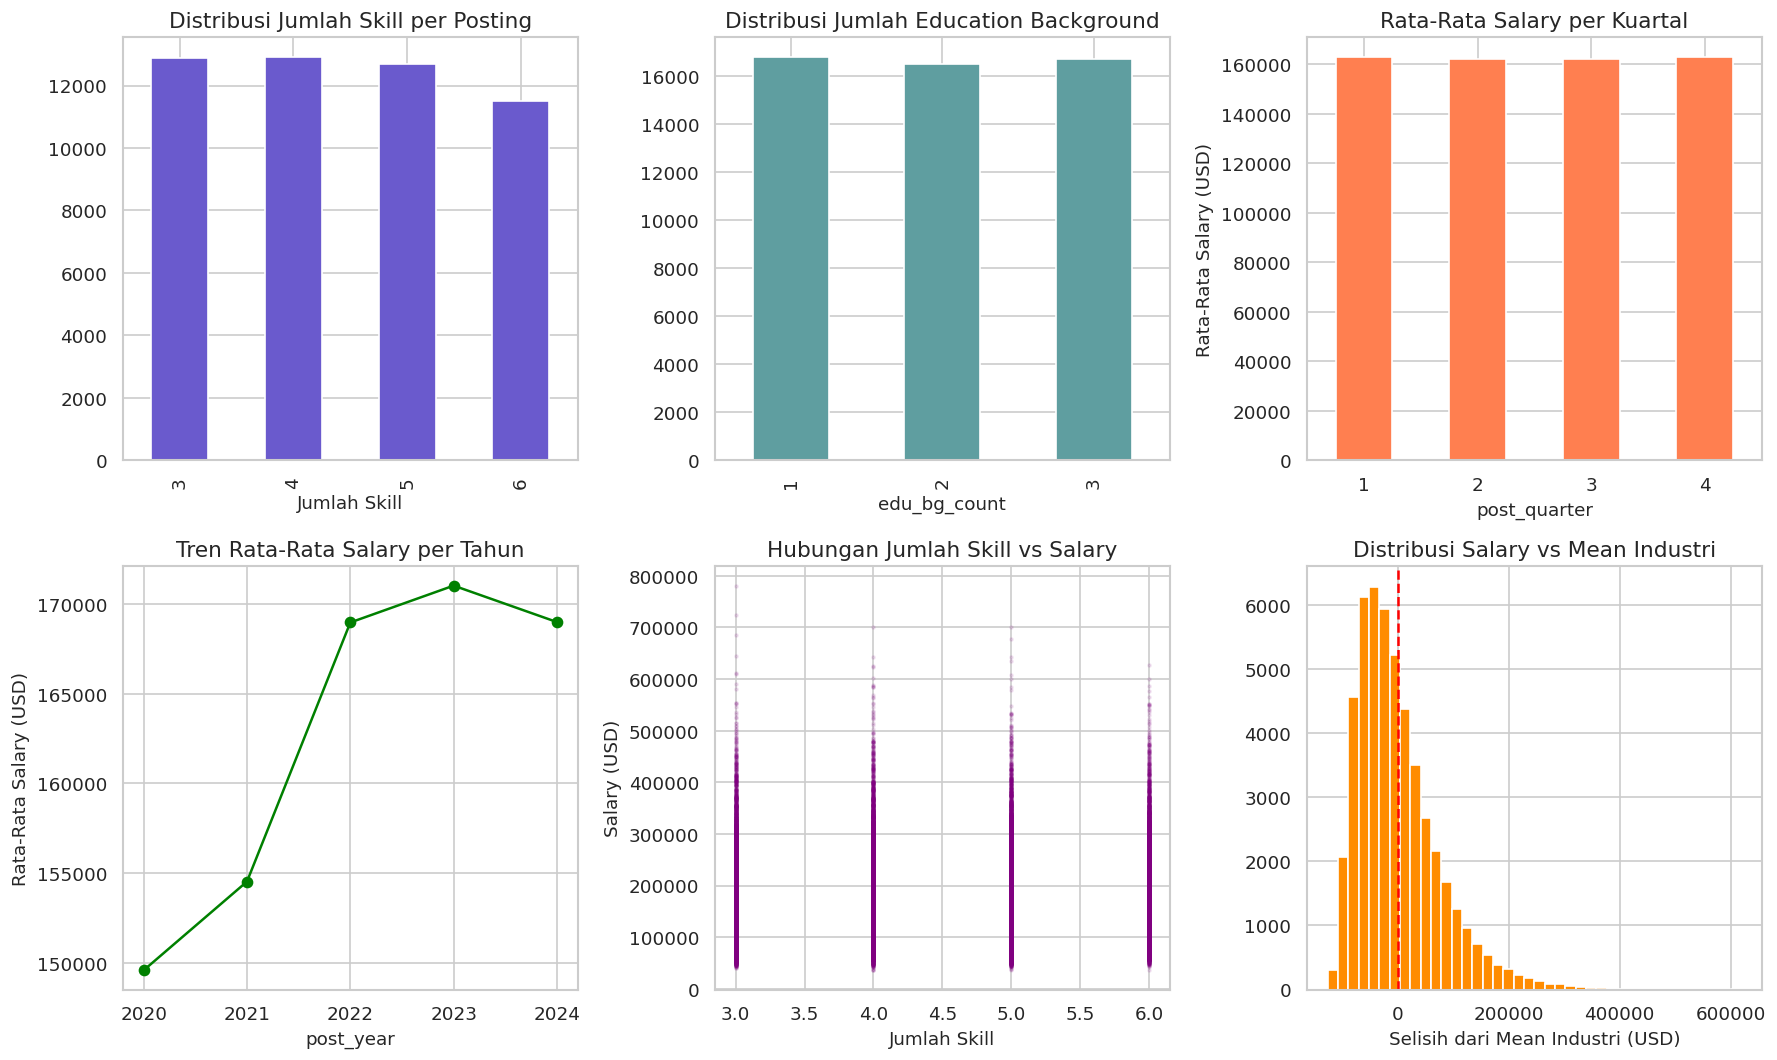


Insight Feature Engineering:
  • Korelasi jumlah skill vs salary: 0.0195
  • Kuartal dengan rata-rata salary tertinggi: Q1


In [ ]:
# Fitur Temporal dari post_date
df['post_month']     = df['post_date'].dt.month
df['post_quarter']   = df['post_date'].dt.quarter
df['post_year']      = df['post_date'].dt.year

# Fitur Jumlah Skill (skill_count) ─
df['skill_count'] = df['skills_required'].str.split('|').apply(len)

# Fitur Jumlah Education Background
df['edu_bg_count'] = df['education_background'].str.split('|').apply(len)

# Salary Relatif terhadap Industri (salary_vs_industry_mean)
industry_mean_salary = df.groupby('industry')['salary_midpoint'].transform('mean')
df['salary_vs_industry_mean'] = df['salary_midpoint'] - industry_mean_salary

# Salary Relatif terhadap Education Level
edu_mean_salary = df.groupby('education_required')['salary_midpoint'].transform('mean')
df['salary_vs_edu_mean'] = df['salary_midpoint'] - edu_mean_salary

print("Fitur-fitur baru yang ditambahkan:")
new_features = ['post_month', 'post_quarter', 'post_year', 'skill_count',
                'edu_bg_count', 'salary_vs_industry_mean', 'salary_vs_edu_mean']
print(df[new_features].describe().round(2))

# Visualisasi fitur baru
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

df['skill_count'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='slateblue', edgecolor='white')
axes[0,0].set_title('Distribusi Jumlah Skill per Posting')
axes[0,0].set_xlabel('Jumlah Skill')

df['edu_bg_count'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='cadetblue', edgecolor='white')
axes[0,1].set_title('Distribusi Jumlah Education Background')

df.groupby('post_quarter')['salary_midpoint'].mean().plot(kind='bar', ax=axes[0,2], color='coral', edgecolor='white')
axes[0,2].set_title('Rata-Rata Salary per Kuartal')
axes[0,2].set_ylabel('Rata-Rata Salary (USD)')
axes[0,2].tick_params(axis='x', rotation=0)

df.groupby('post_year')['salary_midpoint'].mean().plot(marker='o', ax=axes[1,0], color='green')
axes[1,0].set_title('Tren Rata-Rata Salary per Tahun')
axes[1,0].set_ylabel('Rata-Rata Salary (USD)')

axes[1,1].scatter(df['skill_count'], df['salary_midpoint'], alpha=0.1, color='purple', s=3)
axes[1,1].set_title('Hubungan Jumlah Skill vs Salary')
axes[1,1].set_xlabel('Jumlah Skill')
axes[1,1].set_ylabel('Salary (USD)')

axes[1,2].hist(df['salary_vs_industry_mean'], bins=40, color='darkorange', edgecolor='white')
axes[1,2].set_title('Distribusi Salary vs Mean Industri')
axes[1,2].set_xlabel('Selisih dari Mean Industri (USD)')
axes[1,2].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print("\nInsight Feature Engineering:")
corr_skill = df['skill_count'].corr(df['salary_midpoint'])
print(f"  • Korelasi jumlah skill vs salary: {corr_skill:.4f}")
best_quarter = df.groupby('post_quarter')['salary_midpoint'].mean().idxmax()
print(f"  • Kuartal dengan rata-rata salary tertinggi: Q{best_quarter}")

# **10. Data Preprocessing untuk Model Deep Learning**

## Desain Fitur dengan Feature Engineering

| Kolom | Tipe | Encoding | Alasan |
|---|---|---|---|
| `education_required` | Ordinal Categorical | `OrdinalEncoder` | Ada urutan hierarki |
| `seniority_eda` | Ordinal Categorical | `OrdinalEncoder` | Ada urutan hierarki |
| `work_type` | Nominal Categorical | `OrdinalEncoder` | Low cardinality (3 kategori) |
| `industry` | Nominal Categorical | `OrdinalEncoder` | 11 kategori |
| `skills_required` | Multi-label | `MultiLabelBinarizer` | Setiap baris bisa punya banyak skill |
| `education_background` | Multi-label | `MultiLabelBinarizer` | Sama dengan skills_required |
| `min_GPA_requirement` | Numerical | Passthrough | Sudah skala kecil (0–4) |
| `post_quarter` | Numerical | Passthrough | Fitur baru temporal |
| `post_year` | Numerical | Passthrough | Fitur baru temporal |
| `skill_count` | Numerical | Passthrough | Fitur baru agregat |
| `edu_bg_count` | Numerical | Passthrough | Fitur baru agregat |
| **Target: `job_title`** | Categorical | `LabelEncoder` | Integer class index |

## 10.1 Encoding Ordinal

In [ ]:
education_order = ["High School", "Associate", "Bootcamp", "Bachelor's", "Master's", "PhD"]

# Wrap education_order in a list because df[['education_required']] is a DataFrame (2D)
encoder_edu  = OrdinalEncoder(categories=[education_order],  handle_unknown='use_encoded_value', unknown_value=-1)

edu_encoded  = encoder_edu.fit_transform(df[['education_required']])

print("education_required mapping:")
for i, cat in enumerate(education_order): print(f"  {cat} → {i}")
# print("\nseniority mapping:")
# for i, cat in enumerate(seniority_order[0]): print(f"  {cat} → {i}")
# print("\nwork_type categories:", encoder_work.categories_)
# print("industry categories:", encoder_ind.categories_)

education_required mapping:
  High School → 0
  Associate → 1
  Bootcamp → 2
  Bachelor's → 3
  Master's → 4
  PhD → 5


## 10.2 Encoding Multi-Label

In [ ]:
df['skills_list'] = df['skills_required'].apply(
    lambda x: [s.strip() for s in str(x).split('|') if s.strip()])
mlb_skills = MultiLabelBinarizer()
skills_encoded = mlb_skills.fit_transform(df['skills_list'])
skills_df = pd.DataFrame(skills_encoded, columns=['skill_' + c for c in mlb_skills.classes_])

df['edu_bg_list'] = df['education_background'].apply(
    lambda x: [s.strip() for s in str(x).split('|') if s.strip()])
mlb_edu_bg = MultiLabelBinarizer()
edu_bg_encoded = mlb_edu_bg.fit_transform(df['edu_bg_list'])
edu_bg_df = pd.DataFrame(edu_bg_encoded, columns=['edu_bg_' + c for c in mlb_edu_bg.classes_])

print(f"Skills encoded shape        : {skills_df.shape}")
print(f"Education background shape  : {edu_bg_df.shape}")
display(skills_df.head(3))

Skills encoded shape        : (50000, 82)
Education background shape  : (50000, 13)


,skill_A/B Testing,skill_AWS,skill_Accounting,skill_Adobe XD,skill_Agile,skill_Airflow,skill_Analytics,skill_Azure,skill_Bloomberg,skill_Budgeting,...,skill_Supply Chain,skill_System Design,skill_Tableau,skill_Talent Acquisition,skill_TensorFlow,skill_Terraform,skill_TypeScript,skill_Usability Testing,skill_User Research,skill_dbt
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


## 10.3 Encoding Target Variable

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['job_title'])

print(f"Jumlah kelas (job_title): {len(label_encoder.classes_)}")
print("Mapping kelas:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i:>2}: {cls}")

Jumlah kelas (job_title): 20
Mapping kelas:
   0: Backend Developer
   1: Business Analyst
   2: Cloud Architect
   3: Cybersecurity Analyst
   4: Data Analyst
   5: Data Engineer
   6: Data Scientist
   7: DevOps Engineer
   8: Financial Analyst
   9: Frontend Developer
  10: HR Manager
  11: Machine Learning Engineer
  12: Marketing Manager
  13: Operations Manager
  14: Product Manager
  15: Quantitative Analyst
  16: Research Scientist
  17: Senior Software Engineer
  18: Software Engineer
  19: UX Designer


## 10.4 Menggabungkan Semua Fitur → Feature Matrix X

In [ ]:
skills_df.index  = df.index
edu_bg_df.index = df.index

X = pd.concat([
    # Ordinal & nominal
    pd.DataFrame(edu_encoded,  columns=['education_required_ord'], index=df.index),
    # Multi-label
    skills_df,
    edu_bg_df,
    # Numerical (original + engineered)
    df[['min_GPA_requirement']],
], axis=1)

assert not X.columns.duplicated().any(), "Terdapat kolom duplikat di X!"

print(f"Feature matrix X shape : {X.shape}")
print(f"Target y shape         : {y.shape}")
print(f"\nKolom dalam X:")
for col in X.columns:
    print(f"  {col}")
display(X.head(3))

Feature matrix X shape : (50000, 97)
Target y shape         : (50000,)

Kolom dalam X:
  education_required_ord
  skill_A/B Testing
  skill_AWS
  skill_Accounting
  skill_Adobe XD
  skill_Agile
  skill_Airflow
  skill_Analytics
  skill_Azure
  skill_Bloomberg
  skill_Budgeting
  skill_C++
  skill_CI/CD
  skill_CRM
  skill_Compensation
  skill_Compliance
  skill_Content Strategy
  skill_Cost Optimization
  skill_Data Analysis
  skill_Data Visualization
  skill_Derivatives
  skill_Design Thinking
  skill_Digital Marketing
  skill_Docker
  skill_ERP
  skill_Employment Law
  skill_Excel
  skill_FP&A
  skill_Figma
  skill_Financial Modeling
  skill_GCP
  skill_Git
  skill_Google Ads
  skill_HRIS
  skill_HTML/CSS
  skill_Incident Response
  skill_Java
  skill_JavaScript
  skill_Kafka
  skill_Kubernetes
  skill_Lean
  skill_Linux
  skill_MLOps
  skill_Machine Learning
  skill_Microservices
  skill_Network Security
  skill_Penetration Testing
  skill_Performance Management
  skill_PostgreSQL
 

,education_required_ord,skill_A/B Testing,skill_AWS,skill_Accounting,skill_Adobe XD,skill_Agile,skill_Airflow,skill_Analytics,skill_Azure,skill_Bloomberg,...,edu_bg_Industrial Engineering,edu_bg_Informatics Engineering,edu_bg_Information Systems,edu_bg_Law,edu_bg_Management,edu_bg_Mathematics,edu_bg_Mechanical Engineering,edu_bg_Psychology,edu_bg_Statistics,min_GPA_requirement
0,3.0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,3.30
1,3.0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,3.76
2,5.0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,3.59


## 10.5 Train / Validation / Test Split (60/20/20, Stratified)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print("=== Data Split Summary ===")
print(f"X_train : {X_train.shape}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"X_val   : {X_val.shape}    ({len(X_val)/len(X)*100:.1f}%)")
print(f"X_test  : {X_test.shape}   ({len(X_test)/len(X)*100:.1f}%)")
print()
print("Distribusi kelas (y_train):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]:<35}: {c} ({c/len(y_train)*100:.1f}%)")

=== Data Split Summary ===
X_train : (30000, 97)  (60.0%)
X_val   : (10000, 97)    (20.0%)
X_test  : (10000, 97)   (20.0%)

Distribusi kelas (y_train):
  Backend Developer                  : 1505 (5.0%)
  Business Analyst                   : 1546 (5.2%)
  Cloud Architect                    : 1500 (5.0%)
  Cybersecurity Analyst              : 1524 (5.1%)
  Data Analyst                       : 1494 (5.0%)
  Data Engineer                      : 1466 (4.9%)
  Data Scientist                     : 1498 (5.0%)
  DevOps Engineer                    : 1499 (5.0%)
  Financial Analyst                  : 1491 (5.0%)
  Frontend Developer                 : 1444 (4.8%)
  HR Manager                         : 1464 (4.9%)
  Machine Learning Engineer          : 1522 (5.1%)
  Marketing Manager                  : 1508 (5.0%)
  Operations Manager                 : 1502 (5.0%)
  Product Manager                    : 1465 (4.9%)
  Quantitative Analyst               : 1549 (5.2%)
  Research Scientist            

## 10.6 Scalling Feature Numerical

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_gpa = MinMaxScaler()

# fit HANYA dari train, transform ke semua split
X_train['min_GPA_requirement'] = scaler_gpa.fit_transform(X_train[['min_GPA_requirement']])
X_val['min_GPA_requirement']   = scaler_gpa.transform(X_val[['min_GPA_requirement']])
X_test['min_GPA_requirement']  = scaler_gpa.transform(X_test[['min_GPA_requirement']])

print(X_train['min_GPA_requirement'].describe())
display(X_train.head(3))

count    30000.000000
mean         0.498602
std          0.289614
min          0.000000
25%          0.250000
50%          0.500000
75%          0.750000
max          1.000000
Name: min_GPA_requirement, dtype: float64


,education_required_ord,skill_A/B Testing,skill_AWS,skill_Accounting,skill_Adobe XD,skill_Agile,skill_Airflow,skill_Analytics,skill_Azure,skill_Bloomberg,...,edu_bg_Industrial Engineering,edu_bg_Informatics Engineering,edu_bg_Information Systems,edu_bg_Law,edu_bg_Management,edu_bg_Mathematics,edu_bg_Mechanical Engineering,edu_bg_Psychology,edu_bg_Statistics,min_GPA_requirement
15931,5.0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0.3250
16975,1.0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.6500
27811,5.0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0.7625


## 10.7 Simpan Artefak Preprocessing

In [ ]:
joblib.dump(encoder_edu,   'encoder_education_required.pkl')
joblib.dump(mlb_skills,    'mlb_skills.pkl')
joblib.dump(mlb_edu_bg,    'mlb_edu_bg.pkl')
joblib.dump(label_encoder, 'label_encoder_job_title.pkl')
joblib.dump(scaler_gpa,    'scaler_GPA_requirement.pkl')

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv',     index=False)
X_test.to_csv('X_test.csv',   index=False)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
np.save('y_test.npy',  y_test)

print("Semua artefak preprocessing berhasil disimpan!")
print(f"\nRingkasan:")
print(f"  - Input features (X) : {X_train.shape[1]} kolom")
print(f"  - Output classes (y) : {len(label_encoder.classes_)} kelas")
print(f"  - Train samples      : {len(X_train):,}")
print(f"  - Val samples        : {len(X_val):,}")
print(f"  - Test samples       : {len(X_test):,}")

Semua artefak preprocessing berhasil disimpan!

Ringkasan:
  - Input features (X) : 97 kolom
  - Output classes (y) : 20 kelas
  - Train samples      : 30,000
  - Val samples        : 10,000
  - Test samples       : 10,000


---
## Ringkasan Pipeline Data Science Tech Stack

```
Raw CSV (50,743 rows × 26 columns)
    │
    ▼ [3] Data Wrangling
    │  • Drop 12 kolom tidak relevan
    │  • Fix tipe data: post_date → datetime
    │  • Ekstrak year_eda & seniority_eda untuk EDA
    │  • Drop missing values (~1%)
    │  • Drop 223 duplikat
    │
    ▼ Clean DataFrame (~50.000 rows)
    │
    ▼ [4] EDA (9 kolom dieksplorasi, distribusi + insight)
    │
    ▼ [5] Explanatory Analysis (5 business questions terjawab)
    │
    ▼ [6] Conclusion & Recomendation
    │
    ▼ [7] Feature Importance (4 fitur dipilih berdasarkan pertimbangan hasil Feature Importance dan konteks bisnis)
    │
    ▼ [8] Data Dictionary (4 fitur didokumentasikan)
    │
    ▼ [9] Feature Engineering (5 fitur baru: temporal + agregat)
    │  • post_month, post_quarter, post_year
    │  • skill_count, edu_bg_count
    │  • salary_vs_industry_mean, salary_vs_edu_mean
    │
    ▼ [10] Data Preprocessing
    │  • OrdinalEncoder  : education_required, seniority, work_type, industry
    │  • MultiLabelBinarizer : skills_required (~82 fitur), education_background (~13 fitur)
    │  • Passthrough     : min_GPA_requirement + 4 engineered features
    │  • LabelEncoder    : job_title (20 kelas)
    │
    ▼ Feature Matrix X (shape: N × ~106 fitur)
    │
    ▼ Train/Val/Test Split (60/20/20, stratified)
    │
    ▼ SIAP untuk Modelling
         • MLP
```
